# Kinematics across trials

In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas as pd
from __future__ import annotations

# from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict

from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin

In [3]:
data_dir='/data/bnd-data/raw/'
session='M061_2025_03_06_14_00'

In [4]:
df_ = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)
df_ = dsp.preprocess(
    df_,
    only_trials=False,
    combine_time_bins=False, 
    # repair_time_varying_fields=['MotSen1_X', 'MotSen1_Y']
)

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)


In [ ]:
# df = pyal.select_trials(df_, df_.trial_name == 'trial')
# df = dt.add_bhv(df_)
# df = dt.add_pca_df(df)
# df = kin.drop_immobile_trials_from_td(df, win=40, p=1, event_onset=(100, 200))


In [190]:
df.head()

,animal,session,trial_id,trial_name,trial_length,bin_size,idx_trial_start,idx_trial_end,idx_CPI,values_before_camera_trigger,...,MOp_spikes,all_rates,SSp_rates,VAL_rates,GPe_rates,CP_rates,MOp_rates,sol_level_id,sol_contra_ipsi,bhv
0,M061,M061_2025_03_06_14_00,2,trial,600,0.01,60500,61099,[],[],...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.093070924, 0.0, 0.0, 15.6925535, 0.4696169...","[[8.749083, 0.0, 15.5882435, 0.0, 0.0, 0.0, 0....","[[0.2762286, 32.52908, 0.0013355394, 7.811231,...","[[53.410454, 10.727865, 66.73731, 0.0, 0.0, 51...","[[29.476328, 53.33859, 23.22654, 29.499859, 8....","[[32.81393, 0.0, 9.317302, 0.7749599, 0.0, 0.0...",0.0,0.0,"[[-8.308413052944957, 11.259493161075184, 217...."
1,M061,M061_2025_03_06_14_00,4,trial,600,0.01,61200,61799,[],[],...,"[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 5.5446486, 0.0, 0.0, 0.0...","[[0.27375525, 0.0, 0.0, 3.9031663, 0.0, 0.0, 0...","[[24.443327, 15.181539, 0.1257371, 31.301853, ...","[[48.039776, 26.062391, 34.26858, 0.0, 0.0, 46...","[[0.23629218, 46.143555, 33.883762, 17.946896,...","[[19.438744, 0.0, 26.681507, 0.0, 0.0, 0.0, 0....",1.0,0.0,"[[-6.609595859201188, 11.812341121485844, 218...."
2,M061,M061_2025_03_06_14_00,6,trial,600,0.01,62300,62899,[],[],...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[36.172363, 0.0, 0.0, 24.762882, 25.877794, 0...","[[15.7517, 4.8779242e-05, 0.0, 0.0, 0.00474381...","[[16.315289, 52.443726, 18.065641, 0.0, 0.0003...","[[46.300278, 15.6517105, 53.41636, 0.0, 0.0, 6...","[[0.0021536883, 60.416218, 28.896454, 10.49675...","[[15.0233135, 0.0, 1.5043623, 0.0, 0.0, 0.0, 0...",1.0,0.0,"[[-5.319521453932582, 10.00921406311837, 211.2..."
3,M061,M061_2025_03_06_14_00,8,trial,600,0.01,63400,63999,[],[],...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.00089810096, 0.0, 0.000521073, 0.0, 0...","[[15.566815, 0.026170593, 0.0, 0.0, 0.0, 0.0, ...","[[27.833752, 33.456306, 27.930204, 43.580418, ...","[[24.143513, 3.9129512, 35.868313, 0.0, 0.0, 1...","[[2.005567, 33.85045, 27.861921, 39.591812, 0....","[[1.5041213, 0.0, 10.553282, 0.0, 0.0, 0.0, 0....",0.0,1.0,"[[-7.101308457078938, 10.883064750144056, 211...."
4,M061,M061_2025_03_06_14_00,10,trial,600,0.01,64500,65099,[],[],...,"[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0022323057, 0.0, 0.0, 54.192406, 1.3178213...","[[4.8779242e-05, 4.8779242e-05, 0.0, 0.0, 0.27...","[[14.679855, 17.06383, 10.602128, 37.506157, 1...","[[34.104385, 36.875553, 38.693394, 0.0, 0.0, 4...","[[2.2660065, 69.31302, 33.853176, 28.293697, 0...","[[42.28235, 0.0, 10.449963, 0.0021049092, 0.0,...",1.0,0.0,"[[-2.4080383315543563, 11.802780313638689, 215..."


In [246]:
def compute_peak_freq_pre_perturb(bhv_arr, nperseg=None, noverlap=None):
    freqs, psd = scipy.signal.welch(
        bhv_arr, fs=100, nperseg=nperseg, noverlap=noverlap, axis=0
    )
    return freqs[np.argmax(psd, axis=0)]

bhv_field = 'left_knee'
powers = []
for bhv_field in ['left_knee', 'right_knee']:
    # bhv_arr = np.concatenate([df[bhv_field].values[1], df[bhv_field].values[2]])[:, -1]
    bhv_arr = df[bhv_field].values[3][:, 2]
    peak_freq = compute_peak_freq_pre_perturb(bhv_arr)
    print(peak_freq)
    power = dsp.get_power_in_freq_range(bhv_arr, fs=100, freqs=(peak_freq - 0.5, peak_freq + 1))
    powers.append(power)

powers = np.array(powers)

7.0
7.0


/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/scipy/signal/_spectral_py.py:600: UserWarning: nperseg = 256 is greater than input length  = 100, using nperseg = 100
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/scipy/signal/_spectral_py.py:600: UserWarning: nperseg = 256 is greater than input length  = 100, using nperseg = 100
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


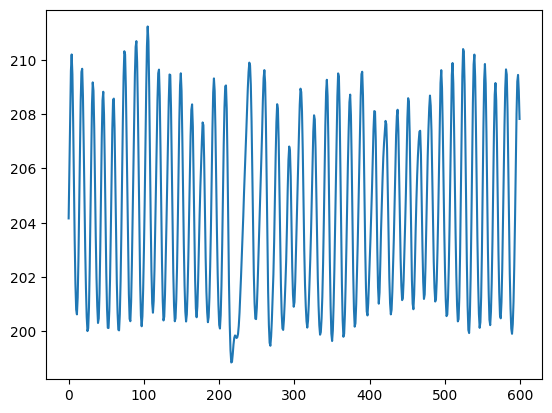

In [207]:
plt.plot(bhv_arr)

In [236]:
i = 2
np.concatenate([df_.iloc[i-1]['left_knee'][:, 2], df_.iloc[i]['left_knee'][:, 2]]).shape

(1100,)

In [5]:
def concat_bhv(df, col=['left_knee', 'right_knee'], new_col='bhv_concat', dim_=2):
    df = df.copy()
    df[new_col] = pd.Series([None] * len(df), dtype="object")
    df["concat_perturb_time"] = pd.Series([None] * len(df), dtype="object")

    n = len(df)

    # IMPORTANT: iterate by POSITION so df.iloc[pos±1] is always valid
    for pos in range(n):
        row = df.iloc[pos]
        if row.trial_name != "trial":
            continue
        if pos == 0 or pos == n - 1:
            continue

        def as_time_x_features(r):
            # each r[c] assumed shape (T, D); take one dim -> (T,)
            return np.column_stack([np.asarray(r[c])[:, dim_] for c in col])  # (T, n_features)

        prev_tf = as_time_x_features(df.iloc[pos - 1])  # (T, n_features)
        curr_tf = as_time_x_features(df.iloc[pos])      # (T, n_features)
        next_tf = as_time_x_features(df.iloc[pos + 1])  # (T, n_features)

        df.at[df.index[pos], new_col] = np.concatenate([prev_tf, curr_tf, next_tf], axis=0)  # (3T, n_features)
        df.at[df.index[pos], "concat_perturb_time"] = df.iloc[pos - 1].trial_length + 200

    return df




In [275]:
df.bhv_concat.values[2].shape

(1200, 2)

In [10]:
df[:10]

,animal,session,trial_id,trial_name,trial_length,bin_size,idx_trial_start,idx_trial_end,idx_CPI,values_before_camera_trigger,...,all_rates,SSp_rates,VAL_rates,GPe_rates,CP_rates,MOp_rates,sol_level_id,sol_contra_ipsi,bhv_concat,concat_perturb_time
0,M061,M061_2025_03_06_14_00,0,free,60000,0.01,0,59999,[],1.0,...,"[[0.0, 0.0, 0.0, 1.0328922, 0.0, 0.51256394, 0...","[[0.0, 8.749083, 0.00012739658, 0.0, 0.0102808...","[[1.8788582, 33.536736, 1.7400755, 12.799794, ...","[[59.259827, 31.873262, 22.325476, 0.0, 0.0, 2...","[[0.0, 49.28063, 15.566815, 33.043465, 0.08489...","[[0.0, 0.0, 2.1744087, 0.0, 2.7606552, 0.0, 0....",NaN,NaN,None,None
1,M061,M061_2025_03_06_14_00,1,intertrial,500,0.01,60000,60499,[],[],...,"[[6.947399, 0.0, 0.0, 55.07608, 3.9026704, 26....","[[11.071746, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...","[[12.006422, 60.700893, 56.523605, 15.566815, ...","[[16.287483, 43.7697, 29.880617, 0.0, 0.0, 116...","[[0.0, 54.803707, 3.2647038, 7.2447352, 0.0, 0...","[[0.0, 2.7606552, 51.021427, 0.0, 28.884914, 0...",NaN,NaN,None,None
2,M061,M061_2025_03_06_14_00,2,trial,600,0.01,60500,61099,[],[],...,"[[0.093070924, 0.0, 0.0, 15.6925535, 0.4696169...","[[8.749083, 0.0, 15.5882435, 0.0, 0.0, 0.0, 0....","[[0.2762286, 32.52908, 0.0013355394, 7.811231,...","[[53.410454, 10.727865, 66.73731, 0.0, 0.0, 51...","[[29.476328, 53.33859, 23.22654, 29.499859, 8....","[[32.81393, 0.0, 9.317302, 0.7749599, 0.0, 0.0...",0.0,0.0,"[[210.9137619399828, 206.4554805655628], [208....",700
3,M061,M061_2025_03_06_14_00,3,intertrial,100,0.01,61100,61199,[],[],...,"[[15.566815, 0.0, 0.0, 3.9856367, 8.749083, 0....","[[0.0021049092, 0.04294701, 0.0, 0.0, 4.877924...","[[11.712245, 36.027554, 0.0, 36.17494, 3.65789...","[[27.50342, 2.4325833, 41.87799, 0.0, 0.0, 57....","[[0.021426776, 69.542, 11.996277, 39.527187, 0...","[[2.7820818, 0.0, 15.80465, 0.0, 0.0, 0.0, 0.0...",NaN,NaN,None,None
4,M061,M061_2025_03_06_14_00,4,trial,600,0.01,61200,61799,[],[],...,"[[0.0, 0.0, 0.0, 0.0, 5.5446486, 0.0, 0.0, 0.0...","[[0.27375525, 0.0, 0.0, 3.9031663, 0.0, 0.0, 0...","[[24.443327, 15.181539, 0.1257371, 31.301853, ...","[[48.039776, 26.062391, 34.26858, 0.0, 0.0, 46...","[[0.23629218, 46.143555, 33.883762, 17.946896,...","[[19.438744, 0.0, 26.681507, 0.0, 0.0, 0.0, 0....",1.0,0.0,"[[206.8606672779244, 206.5766548637997], [208....",300
5,M061,M061_2025_03_06_14_00,5,intertrial,500,0.01,61800,62299,[],[],...,"[[0.0, 0.0, 0.0, 0.0, 1.2302874, 0.0, 0.0, 0.0...","[[12.2605, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[[18.51603, 52.281567, 22.71725, 28.421453, 0....","[[46.858177, 10.597, 53.921318, 0.0, 0.0, 63.9...","[[3.1095927, 48.11395, 15.290167, 25.426794, 0...","[[16.036482, 0.0, 17.859201, 12.363018, 0.0, 0...",NaN,NaN,None,None
6,M061,M061_2025_03_06_14_00,6,trial,600,0.01,62300,62899,[],[],...,"[[36.172363, 0.0, 0.0, 24.762882, 25.877794, 0...","[[15.7517, 4.8779242e-05, 0.0, 0.0, 0.00474381...","[[16.315289, 52.443726, 18.065641, 0.0, 0.0003...","[[46.300278, 15.6517105, 53.41636, 0.0, 0.0, 6...","[[0.0021536883, 60.416218, 28.896454, 10.49675...","[[15.0233135, 0.0, 1.5043623, 0.0, 0.0, 0.0, 0...",1.0,0.0,"[[200.07289867245223, 203.12909960725423], [19...",700
7,M061,M061_2025_03_06_14_00,7,intertrial,500,0.01,62900,63399,[],[],...,"[[0.0, 0.0, 4.8779242e-05, 0.0, 0.0, 0.0, 0.0,...","[[0.27375525, 0.27375525, 0.0, 0.0, 1.8788582,...","[[27.461353, 50.43591, 0.0, 21.534988, 0.0, 0....","[[25.756746, 38.051884, 17.427994, 0.0, 0.0, 3...","[[10.606872, 45.844704, 8.548958, 21.624792, 4...","[[21.122381, 0.0, 12.385344, 0.0, 0.0, 0.0, 0....",NaN,NaN,None,None
8,M061,M061_2025_03_06_14_00,8,trial,600,0.01,63400,63999,[],[],...,"[[0.0, 0.00089810096, 0.0, 0.000521073, 0.0, 0...","[[15.566815, 0.026170593, 0.0, 0.0, 0.0, 0.0, ...","[[27.833752, 33.456306, 27.930204, 43.580418, ...","[[24.143513, 3.9129512, 35.868313, 0.0, 0.0, 1...","[[2.005567, 33.85045, 27.861921, 39.591812, 0....","[[1.5041213, 0.0, 10.553282, 0.0, 0.0, 0.0, 0....",0.0,1.0,"[[207.46950738193823, 2

In [277]:
df.bhv_concat.values[6].shape

(1600, 2)

In [289]:
bhv_field = 'left_knee'
powers = []
peak_freqs = compute_peak_freq_pre_perturb(df.bhv_concat.values[2], perturb_idx=df.concat_perturb_time.values[2])
for i, peak_freq in enumerate(peak_freqs):
    power = dsp.get_power_in_freq_range(df.bhv_concat.values[2][:, i], fs=100, freqs=(peak_freq - 1, peak_freq + 1))
    powers.append(power)

powers = np.array(powers)

In [291]:
powers.shape

(2, 1200)

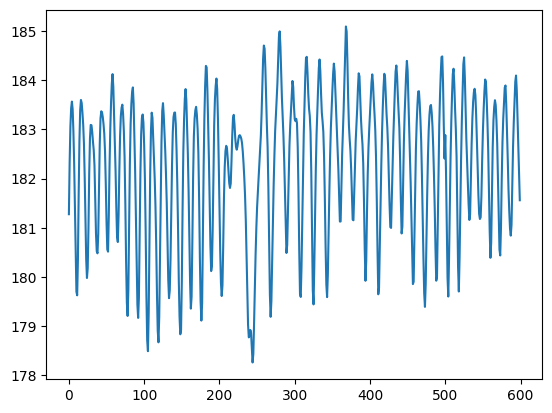

In [397]:
plt.plot(df.left_elbow.values[0][:, 2])

d: 1.104
Bimodal: False
Thresh: 16.59
Dropped 18 of 333 rows (5.41%).


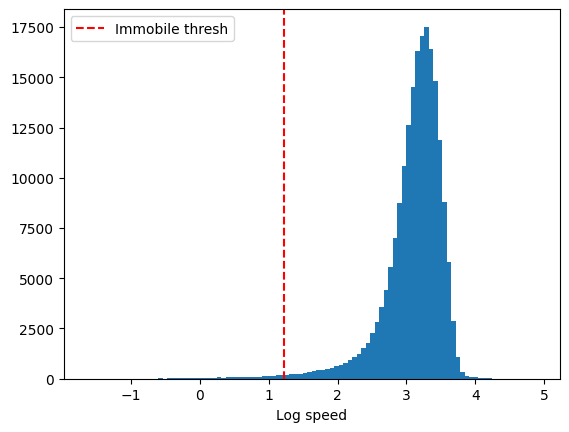

In [404]:
df = concat_bhv(df_, col=('left_knee', 'right_knee'))
df = pyal.select_trials(df, df.trial_name == 'trial')
df = kin.drop_immobile_trials_from_td(df, p=1)

## Run pipeline on session

In [67]:
test = np.concatenate([df_.right_knee.values[1][:, 2], df_.right_knee.values[2][:, 2]], axis=0)

In [68]:
test.shape

(1100,)

(450.0, 550.0)

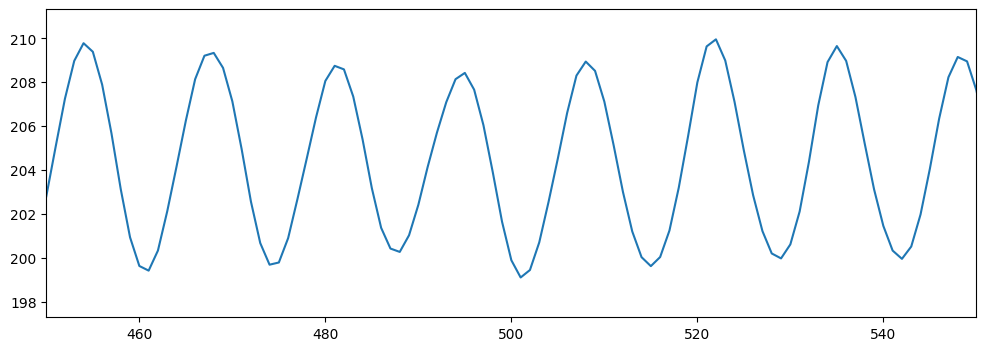

In [62]:
plt.figure(figsize=(12, 4))
plt.plot(test)
plt.xlim(450, 550)

In [124]:
def add_concat_perturb_time(td: pd.DataFrame):
    td = td.copy()
    td["concat_perturb_time"] = pd.Series([None] * len(td), dtype="object")

    for idx, row in td.iterrows():
        if row.trial_name != 'trial':
            continue
        td.at[idx, "concat_perturb_time"] = df.iloc[idx - 1].trial_length + row.idx_sol_on
    return td

In [7]:
df__ = dt.add_pca_df(df_)

## Dirty

In [323]:
df = dt.add_bhv(df__, bhv_fields=['left_paw', 'right_paw'])
df = concat_previous_intertrial_signal(df, 'MOp_rates_pca')
df = concat_previous_intertrial_signal(df, 'bhv', features=[2, 5])
df = add_concat_perturb_time(df)
df = pyal.select_trials(df, df.trial_name == 'trial')
df = compute_power_in_td(df)
# df = add_power_metric_to_df(df)

# mask = df["power_AUC"].apply(
#     lambda x: x is not None and not np.any(np.isnan(x))
# )

# df = df.loc[mask]

# mask = df["concat_perturb_time"].apply(
#     lambda x: x > 300
# )

# df = df.loc[mask]

# df["MOp_rates_pca_concat"] = df.apply(
#     lambda row: row["MOp_rates_pca_concat"][row["concat_perturb_time"] - 500:, :],
#     axis=1
# )

(700, 2)
(300, 2)
(700, 2)
(700, 2)
(700, 2)
(500, 2)
(300, 2)
(700, 2)
(700, 2)
(500, 2)
(300, 2)
(500, 2)
(300, 2)
(300, 2)
(700, 2)
(700, 2)
(300, 2)
(700, 2)
(700, 2)
(700, 2)
(500, 2)
(500, 2)
(500, 2)
(700, 2)
(500, 2)
(700, 2)
(300, 2)
(300, 2)
(300, 2)
(500, 2)
(500, 2)
(300, 2)
(300, 2)
(700, 2)
(700, 2)
(700, 2)
(300, 2)
(500, 2)
(700, 2)
(700, 2)
(700, 2)
(300, 2)
(500, 2)
(700, 2)
(300, 2)
(700, 2)
(300, 2)
(700, 2)
(700, 2)
(700, 2)
(500, 2)
(500, 2)
(500, 2)
(300, 2)
(500, 2)
(300, 2)
(300, 2)
(700, 2)
(700, 2)
(500, 2)
(300, 2)
(300, 2)
(300, 2)
(700, 2)
(500, 2)
(500, 2)
(500, 2)
(300, 2)
(300, 2)
(500, 2)
(500, 2)
(500, 2)
(300, 2)
(500, 2)
(700, 2)
(700, 2)
(300, 2)
(300, 2)
(700, 2)
(500, 2)
(500, 2)
(500, 2)
(700, 2)
(500, 2)
(500, 2)
(300, 2)
(300, 2)
(500, 2)
(500, 2)
(300, 2)
(700, 2)
(500, 2)
(300, 2)
(300, 2)
(500, 2)
(300, 2)
(300, 2)
(300, 2)
(500, 2)
(500, 2)
(500, 2)
(500, 2)
(300, 2)
(700, 2)
(300, 2)
(700, 2)
(700, 2)
(700, 2)
(500, 2)
(300, 2)
(300, 2)
(

700
-2.186773164436923


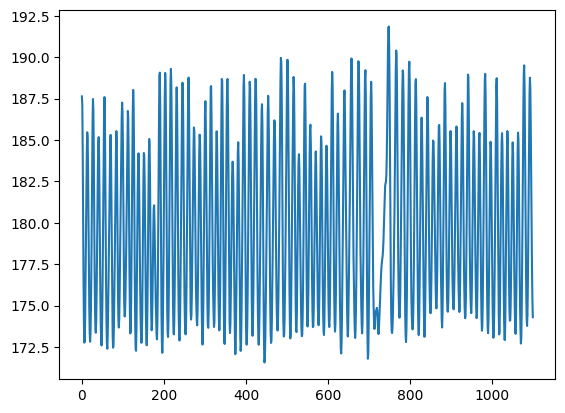

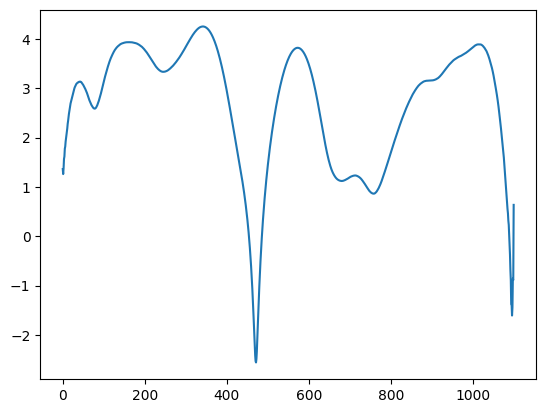

In [229]:
trial = 2
plt.plot(df.bhv_concat.values[trial][:, 0])
plt.figure()
plt.plot(np.log(df.power.values[trial][:, 0]))
print(df.concat_perturb_time.values[trial])
print(df.power_AUC.values[trial][0])

In [267]:
scores_paw = {}
for area in ['MOp']:
    scores_, times = decode.decoding_moving_window_no_time_concat(
        Ridge(alpha=100),
        X=np.stack(df[f'{area}_rates_pca_concat']),
        y=np.stack(df.power_AUC.values),
        window_length_bin=200,
        step_bin=5,
        cv=4
    )
    scores_paw[area] = scores_

  0%|          | 0/141 [00:00<?, ?it/s]

100%|██████████| 141/141 [00:19<00:00,  7.41it/s]


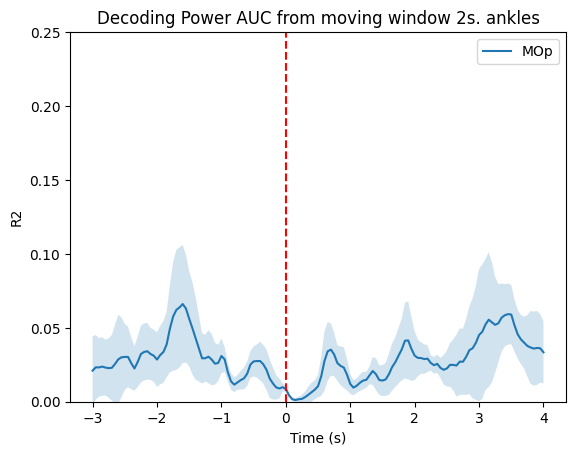

In [ ]:
fig, ax = plt.subplots()
# st
for area in ['MOp']:
    vizutils.shaded_errorbar(ax, times-5, scores_paw[area], label=area)
ax.axvline(0, color='r', linestyle='dashed')
ax.set_xlabel('Time (s)')
ax.set_ylabel('R2')
ax.set_title('Decoding Power AUC from moving window 2s. ankles')
ax.set_ylim(0, 0.25)
ax.legend()

In [136]:
powers.shape

(2, 700)

In [116]:
df.bhv_concat.values[4].shape

(700, 6)

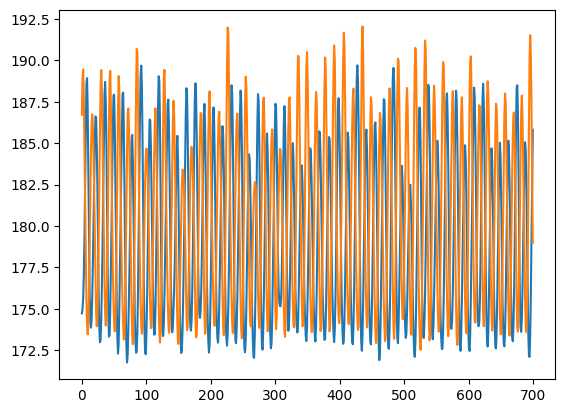

In [120]:
plt.plot(df.bhv_concat.values[4])
# plt.xlim(50, 150)

In [322]:
def compute_peak_freq_pre_perturb(bhv_arr, perturb_idx: int, nperseg=None, noverlap=None):
    print(bhv_arr[:perturb_idx].shape)
    freqs, psd = scipy.signal.welch(
        bhv_arr[:perturb_idx], fs=100, nperseg=nperseg, noverlap=noverlap, axis=0
    )
    return freqs[np.argmax(psd, axis=0)]

def concat_previous_intertrial_signal(td, signal, features: np.ndarray | None = None):
    if features is None:
        features = np.arange(td[signal].values[0].shape[-1])

    td = td.copy()
    new_signal = signal + '_concat'
    td[new_signal] = pd.Series([None] * len(td), dtype="object")

    for pos in range(len(td)):
        row = td.iloc[pos]
        if row.trial_name != "trial":
            continue
        prev_tf = td.iloc[pos-1][signal][:, features]  # (T, n_features)
        curr_tf = td.iloc[pos][signal][:, features]     # (T, n_features)

        td.at[td.index[pos], new_signal] = np.concatenate([prev_tf, curr_tf], axis=0)

    return td


def compute_power_in_td(df, freq_tresh=0.5):
    df = df.copy()
    df['power'] = pd.Series([None] * len(df), dtype="object")
    total_trials = len(df)
    n = 0
    for idx, row in df.iterrows():
        peak_freqs = compute_peak_freq_pre_perturb(row.bhv_concat, perturb_idx=row.concat_perturb_time)
        powers = []
        if any(x < freq_tresh for x in peak_freqs):
            n = n + 1
            continue

        for i, peak_freq in enumerate(peak_freqs):
            power = dsp.get_power_in_freq_range(row.bhv_concat[:, i], fs=100, freqs=(peak_freq - 0.5, peak_freq + 1))
            powers.append(power)
        powers = np.array(powers)
        df.at[idx, 'power'] = powers.T

    print(f"Skipped {n} trials {(n / total_trials) * 100:.2f}")
    return df

def concat_bhv(df, col=['left_knee', 'right_knee'], new_col='bhv_concat', dim_=2):
    df = df.copy()
    df[new_col] = pd.Series([None] * len(df), dtype="object")
    df["concat_perturb_time"] = pd.Series([None] * len(df), dtype="object")

    n = len(df)

    # IMPORTANT: iterate by POSITION so df.iloc[pos±1] is always valid
    for pos in range(n):
        row = df.iloc[pos]
        if row.trial_name != "trial":
            continue
        if pos == 0 or pos == n - 1:
            continue

        def as_time_x_features(r):
            # each r[c] assumed shape (T, D); take one dim -> (T,)
            return np.column_stack([np.asarray(r[c])[:, dim_] for c in col])  # (T, n_features)

        prev_tf = as_time_x_features(df.iloc[pos - 1])  # (T, n_features)
        curr_tf = as_time_x_features(df.iloc[pos])      # (T, n_features)
        # next_tf = as_time_x_features(df.iloc[pos + 1])  # (T, n_features)

        df.at[df.index[pos], new_col] = np.concatenate([prev_tf, curr_tf], axis=0)  # (3T, n_features)
        df.at[df.index[pos], "concat_perturb_time"] = df.iloc[pos - 1].trial_length + 200

    return df

def concat_neural_data(df, col='MOp_rates_pca'):
    new_col = col + '_concat'
    df = df.copy()
    df[new_col] = pd.Series([None] * len(df), dtype="object")
    # df["concat_perturb_time"] = pd.Series([None] * len(df), dtype="object")

    n = len(df)

    # IMPORTANT: iterate by POSITION so df.iloc[pos±1] is always valid
    for pos in range(n):
        row = df.iloc[pos]
        if row.trial_name != "trial":
            continue
        if df.iloc[pos - 1].trial_length == 100:
            continue
        if pos == 0 or pos == n - 1:
            continue

        def as_time_x_features(r, c):
            # each r[c] assumed shape (T, D); take one dim -> (T,)
            return np.column_stack([np.asarray(r[c])])  # (T, n_features)

        prev_tf = as_time_x_features(df.iloc[pos - 1], col)  # (T, n_features)
        curr_tf = as_time_x_features(df.iloc[pos], col)      # (T, n_features)
        # next_tf = as_time_x_features(df.iloc[pos + 1])  # (T, n_features)
        solenoid_onset = df.iloc[pos - 1].trial_length + row.idx_sol_on
        df.at[df.index[pos], new_col] = np.concatenate([prev_tf, curr_tf], axis=0)[solenoid_onset - 500:]
        df.at[df.index[pos], "previous_inter_length"] = df.iloc[pos - 1].trial_length

    return df


@dataclass(frozen=True)
class PerturbationMetrics:
    I_log: float          # integrated |log(P / P_base)|
    A_max: float          # max |P - P_base|
    T_rec: int            # recovery time in samples (relative to perturbation index)
    signed_area: float    # ∫ (P - P_base) dt over post window (in sample-units unless dt provided)


def perturbation_metrics(
    power: np.ndarray,
    perturb_idx: int = 200,
    post_len: int | None = None,
    baseline_len: int | None = None,
    tol_rel: float = 0.10,
    dt: float | None = None,
    eps: float = 1e-12,
) -> PerturbationMetrics:
    """
    Compute 4 scalar metrics from a 1D power time series around a perturbation.

    Metrics
    -------
    I_log:
        Integrated absolute log-ratio: ∫ |log(P / P_base)| dt over post window.
        (If dt is None, integral is in sample-units; otherwise seconds, etc.)
    A_max:
        Peak absolute deviation in linear power: max |P - P_base| over post window.
    T_rec:
        Recovery time in samples after perturbation: first time t such that for all
        subsequent samples P is within +/- tol_rel * P_base. Returns np.nan if never recovers.
    signed_area:
        Signed area under deviation curve: ∫ (P - P_base) dt over post window.

    Parameters
    ----------
    power:
        1D array, length e.g. 600.
    perturb_idx:
        Index of perturbation onset (e.g. 200).
    post_len:
        Number of samples to include after perturbation. Defaults to full remaining length.
    baseline_len:
        Number of samples before perturbation for baseline. Defaults to all pre-perturbation samples.
    tol_rel:
        Relative tolerance for recovery band (e.g., 0.10 = +/-10% of baseline).
    dt:
        Sampling interval. If provided, integrals are scaled by dt.
    eps:
        Small constant to avoid log(0) and division by zero.

    Returns
    -------
    PerturbationMetrics
    """
    p = np.asarray(power, dtype=float).ravel()
    n = p.size
    if n == 0:
        raise ValueError("`power` is empty.")
    if not (0 < perturb_idx < n):
        raise ValueError(f"`perturb_idx` must be in (0, {n-1}), got {perturb_idx}.")

    if baseline_len is None:
        base_start = 0
    else:
        if baseline_len <= 0:
            raise ValueError("`baseline_len` must be positive.")
        base_start = max(0, perturb_idx - baseline_len)

    if post_len is None:
        post_end = n
    else:
        if post_len <= 0:
            raise ValueError("`post_len` must be positive.")
        post_end = min(n, perturb_idx + post_len)

    base = p[base_start:perturb_idx]
    if base.size == 0:
        raise ValueError("Baseline window is empty. Adjust `baseline_len` or `perturb_idx`.")
    p_base = float(np.nanmean(base))
    if not np.isfinite(p_base):
        raise ValueError("Baseline mean is not finite (NaN/inf).")
    if p_base <= 0:
        # Power should typically be >0; allow but guard log-ratio.
        pass

    post = p[perturb_idx:post_end]

    # --- I_log ---
    # Use log(P / P_base); clamp to eps to avoid log(0) and division by 0.
    denom = max(p_base, eps)
    ratio = np.clip(post, eps, np.inf) / denom
    log_ratio = np.log(ratio)
    I_log = float(np.nansum(np.abs(log_ratio)))

    # --- A_max ---
    A_max = float(np.nanmax(np.abs(post - p_base)))

    # --- signed area ---
    signed_area = float(np.nansum(post - p_base))

    # --- T_rec (in samples after perturbation) ---
    # Recovery defined as: from some index onward, always within band.
    lo = (1.0 - tol_rel) * p_base
    hi = (1.0 + tol_rel) * p_base
    within = (post >= lo) & (post <= hi)

    # Find earliest k such that within[k:] are all True.
    # Equivalent: suffix_all_true[k] = all(within[k:]).
    if within.size == 0:
        T_rec = np.nan
    else:
        suffix_all_true = np.logical_and.accumulate(within[::-1])[::-1]
        if not np.any(suffix_all_true):
            T_rec = np.nan
        else:
            T_rec = int(np.argmax(suffix_all_true))  # index within post window

    # Scale integrals by dt if provided
    if dt is not None:
        if dt <= 0:
            raise ValueError("`dt` must be positive.")
        I_log *= dt
        signed_area *= dt

    return PerturbationMetrics(I_log=I_log, A_max=A_max, T_rec=T_rec, signed_area=signed_area)

def add_power_metric_to_df(df):
    df = df.copy()
    df['power_AUC'] = pd.Series(np.nan * len(df), dtype="object")

    for idx, row in df.iterrows():
        if row.power is None:
            continue
        
        signed_area = []
        for power_arr in row.power.T:
            # --- Compute metrics ---
            print(power_arr.shape)
            print(row.trial_id)
            m = perturbation_metrics(
                np.log(power_arr),
                perturb_idx=row.concat_perturb_time - 50,
                # baseline_len=200,   # use all samples 0..199 as baseline
                # post_len=400,       # use 200..599 as post window
                tol_rel=0.10,       # recovery band +/-10% of baseline
                dt=0.01,            # e.g., 100 Hz sampling
            )
            signed_area.append(m.signed_area)
        df.at[idx, 'power_AUC'] = np.array(signed_area)

    return df



In [6]:
ALL_BHV_FIELDS = [
    "left_ankle",
    "left_elbow",
    "left_foot",
    "left_knee",
    "left_paw",
    "left_wrist",
    "right_ankle",
    "right_elbow",
    "right_foot",
    "right_knee",
    "right_paw",
    "right_wrist",
]


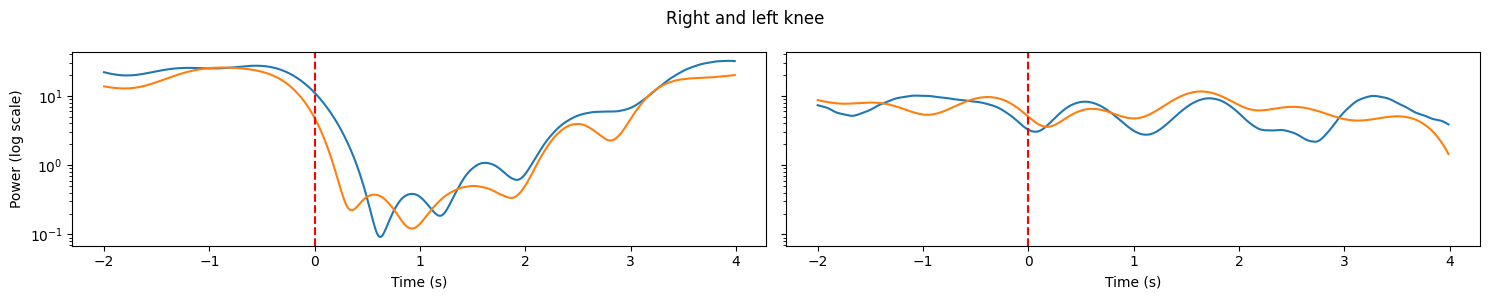

In [31]:
fig, axs = plt.subplots(1, 2, figsize=(15, 3), sharey='all')
ax, ax1 = axs
ax.plot(np.arange(-2, 4, 0.01), powers[0, :, :].T)
ax1.plot(np.arange(-2, 4, 0.01), powers[112, :, :].T)

ax.axvline(0, color='red', linestyle='dashed')
ax1.axvline(0, color='red', linestyle='dashed')

# ax.set_xlim(15, 1200)

ax.set_yscale("log")
ax.set_ylabel("Power (log scale)")
ax.set_xlabel("Time (s)")
ax1.set_xlabel("Time (s)")

plt.suptitle('Right and left knee')
plt.tight_layout()

Dropped 60 trials 18.02
Dropped 46 trials 13.81
Dropped 56 trials 16.82
Dropped 31 trials 9.31
Dropped 30 trials 9.01
Dropped 214 trials 64.26


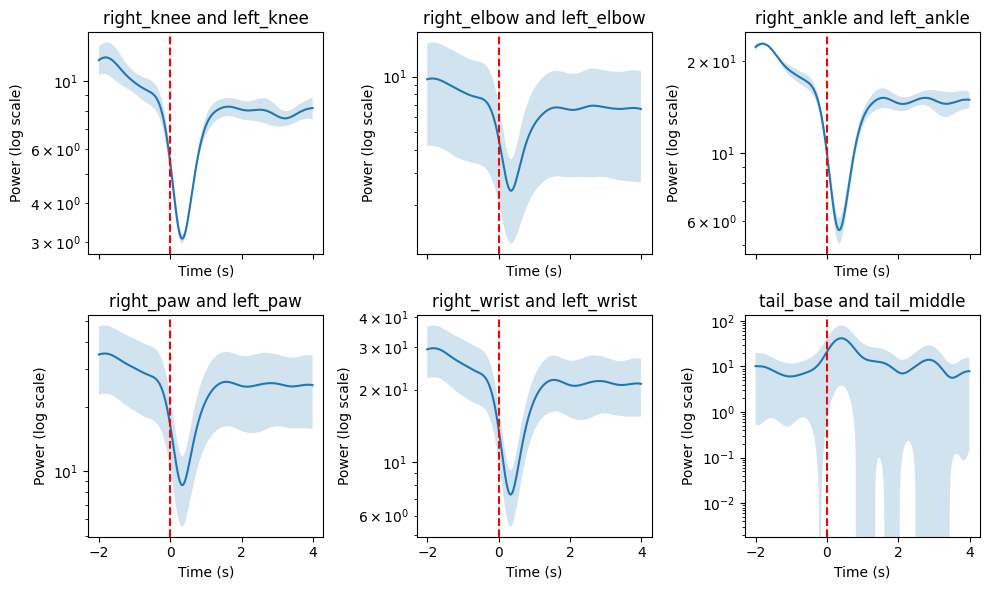

In [86]:
field_combinations = [
    ('right_knee', 'left_knee'),
    ('right_elbow', 'left_elbow'),
    ('right_ankle', 'left_ankle'),
    ('right_paw', 'left_paw'),
    ('right_wrist', 'left_wrist'),
    ('tail_base', 'tail_middle', 'tail_tip')
]
fig, axs = plt.subplots(2, 3, figsize=(10, 6), sharex='all')
axs = axs.flatten()

for field, ax in zip(field_combinations, axs):
    df = concat_bhv(df_, col=field)
    df = pyal.select_trials(df, df.trial_name == 'trial')
    powers = compute_power_in_td(df)
    vizutils.shaded_errorbar(ax, np.arange(-2, 4, 0.01), powers.mean(axis=0).T)
    ax.set_title(f'{field[0]} and {field[1]}')
    ax.set_yscale("log")
    ax.axvline(0, color='red', linestyle='dashed')
    ax.set_ylabel("Power (log scale)")
    ax.set_xlabel("Time (s)")

plt.tight_layout()

In [6]:
df__ = dt.add_pca_df(df_)

In [27]:
df = concat_bhv(df__, col=['left_paw', 'right_paw'])
df = concat_neural_data(df)
df = pyal.select_trials(df, df.trial_name == 'trial')
df, powers = compute_power_in_td(df)
df = add_power_metric_to_df(df)


Dropped 31 trials 9.31


In [31]:
mask = df["power_AUC"].apply(
    lambda x: x is not None and not np.any(np.isnan(x))
)
df = df.loc[mask]

In [38]:
mask = df["MOp_rates_pca_concat"].apply(
    lambda x: x is not None and not np.any(np.isnan(x))
)
df = df.loc[mask]

In [37]:
len(df)

302

In [39]:
scores_paw = {}
for area in ['MOp']:
    scores_, times = decode.decoding_moving_window_no_time_concat(
        Ridge(alpha=100),
        X=np.stack(df[f'{area}_rates_pca_concat']),
        y=np.stack(df.power_AUC.values),
        window_length_bin=200,
        step_bin=5,
        cv=4
    )
    scores_paw[area] = scores_

100%|██████████| 141/141 [00:16<00:00,  8.55it/s]


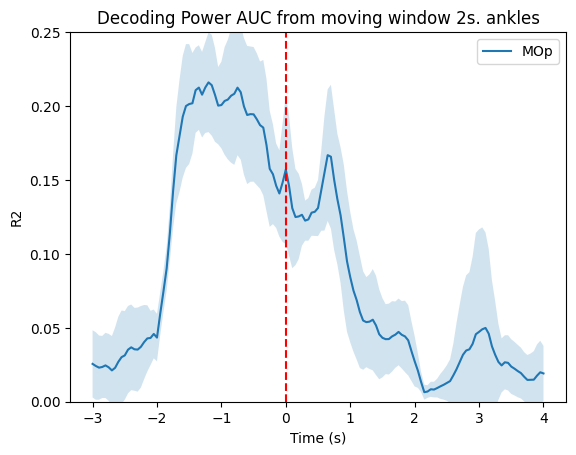

In [128]:
fig, ax = plt.subplots()
# st
for area in ['MOp']:
    vizutils.shaded_errorbar(ax, times-5, scores_paw[area], label=area)
ax.axvline(0, color='r', linestyle='dashed')
ax.set_xlabel('Time (s)')
ax.set_ylabel('R2')
ax.set_title('Decoding Power AUC from moving window 2s. ankles')
ax.set_ylim(0, 0.25)
ax.legend()

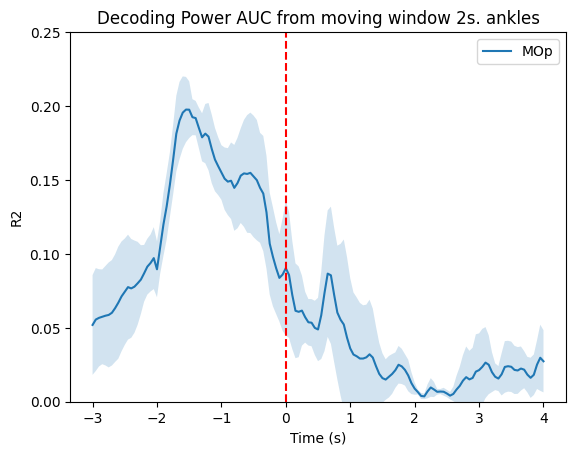

In [40]:
fig, ax = plt.subplots()
# st
for area in ['MOp']:
    vizutils.shaded_errorbar(ax, times-5, scores_paw[area], label=area)
ax.axvline(0, color='r', linestyle='dashed')
ax.set_xlabel('Time (s)')
ax.set_ylabel('R2')
ax.set_title('Decoding Power AUC from moving window 2s. ankles')
ax.set_ylim(0, 0.25)
ax.legend()

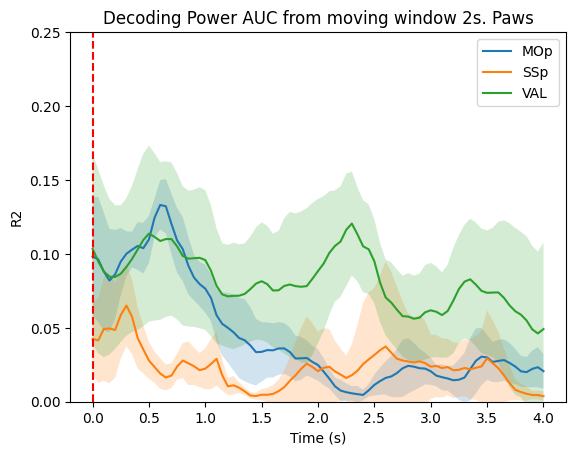

In [328]:
fig, ax = plt.subplots()
# st
for area in ['MOp', 'SSp', 'VAL']:
    vizutils.shaded_errorbar(ax, times-2, scores[area], label=area)
ax.axvline(0, color='r', linestyle='dashed')
ax.set_xlabel('Time (s)')
ax.set_ylabel('R2')
ax.set_title('Decoding Power AUC from moving window 2s. Paws')
ax.set_ylim(0, 0.25)
ax.legend()

Text(0.5, 1.0, 'Decoding Area under Power curve from whole trial')

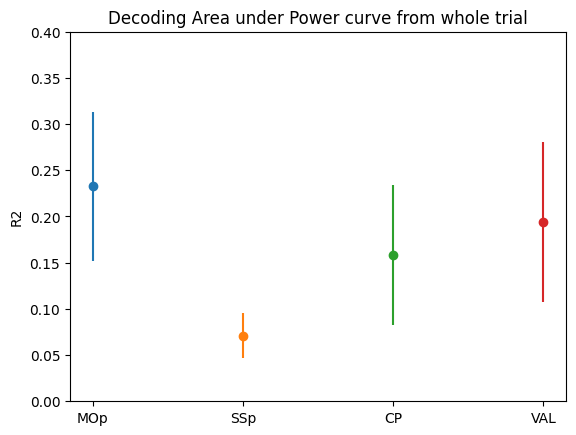

In [288]:
model = Ridge(alpha=100)
fig, ax = plt.subplots()
for area in ['MOp', 'SSp', 'CP', 'VAL']:
    X = np.stack(perturb_td[f'{area}_rates_pca'])[mask, :]
    y = np.stack(perturb_td.power_AUC.values[mask])
    n_trials, n_times, n_comp = X.shape
    

    r2s = cross_val_score(model, X.reshape(-1, n_times * (n_comp)), y, cv=5, scoring=decode.get_custom_scorer())
    ax.errorbar(x=area, y=r2s.mean(), yerr=r2s.std(), fmt='o')
ax.set_ylim(0, 0.4)
ax.set_ylabel('R2')
ax.set_title('Decoding Area under Power curve from whole trial')

In [154]:
y

array([[-71.48441512,  23.83766111,   9.53693308],
       [ -1.92085945,   6.78732024,   0.50931528],
       [-19.40694743,  17.46483935,   6.20584389],
       [-22.39145788,   7.04622926,   7.28081522],
       [-83.89162611,  25.12778554,   8.38641357],
       [-42.6766247 ,  19.84934477,   4.77828771],
       [-57.77974053,  16.88142945,  10.10781963],
       [-80.11819826,  25.94223668,   9.23216362],
       [-50.69653921,  14.79127543,  12.13827935],
       [-26.33986912,  16.89656466,   4.21053422],
       [-14.42644518,  11.26517204,   3.57376356],
       [ 53.61045232,  22.02035212,   4.96593488],
       [-29.36637858,  19.13477429,   3.06689855],
       [-18.08266158,  11.74205792,   2.75796223],
       [-38.58175721,  17.58114112,   3.49276562],
       [-27.84690602,   9.43918586,   5.20592271],
       [  5.54189183,  10.58839535,   1.90171029],
       [-22.78587593,  11.82294073,   3.30203093],
       [ -6.27446654,   9.98978956,   2.7733953 ],
       [  5.24787899,  30.57109

In [30]:
y = y.reshape(-1, 1)
y_hat = y_hat.reshape(-1, 1)
np.corrcoef(y.T, y_hat.T)

AttributeError: 'float' object has no attribute 'shape'

In [27]:
decode.custom_r2_func(y, y_hat)

AttributeError: 'float' object has no attribute 'shape'

In [181]:
df__ = dt.add_pca_df(df_)

Dropped 52 trials 15.62


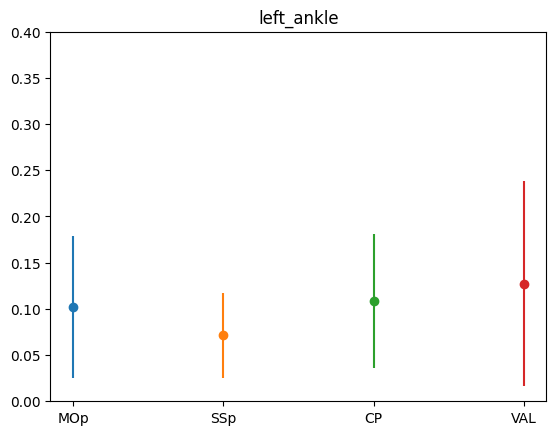

Dropped 46 trials 13.81


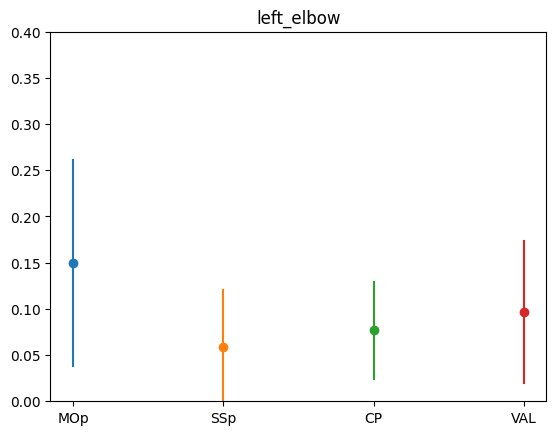

Dropped 40 trials 12.01


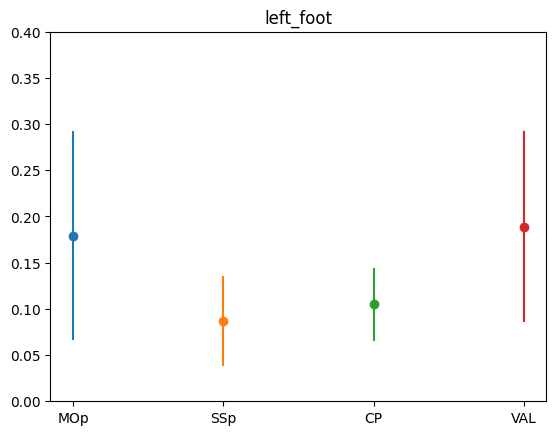

Dropped 56 trials 16.82


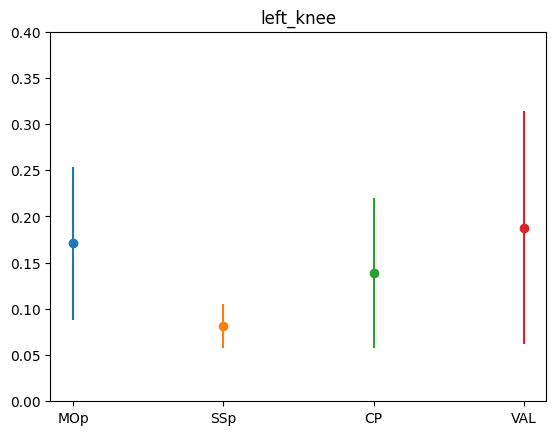

Dropped 30 trials 9.01


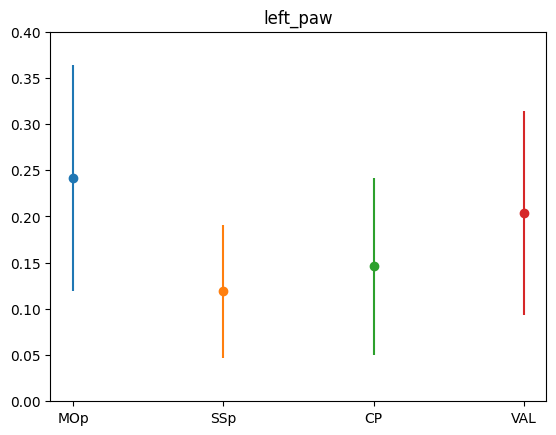

Dropped 27 trials 8.11


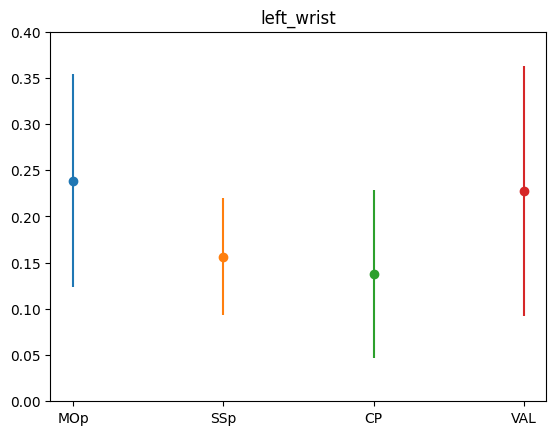

Dropped 39 trials 11.71


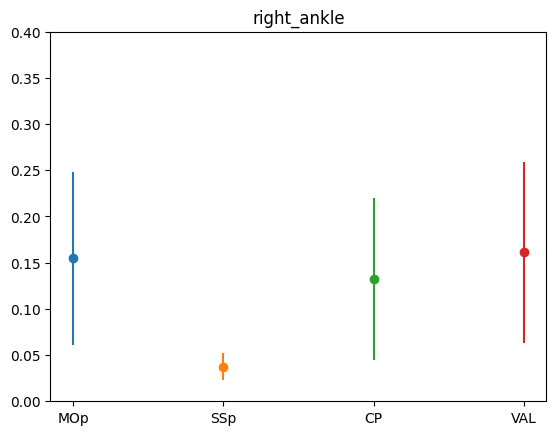

Dropped 22 trials 6.61


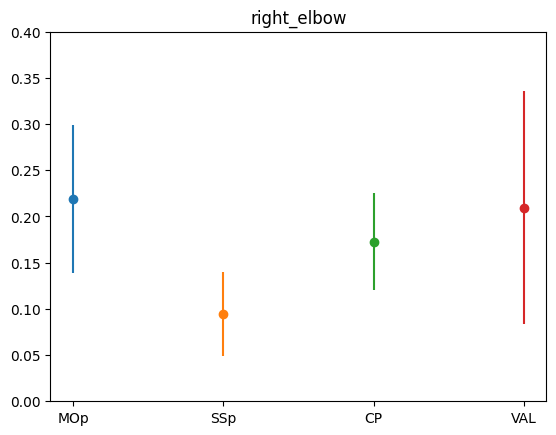

Dropped 24 trials 7.21


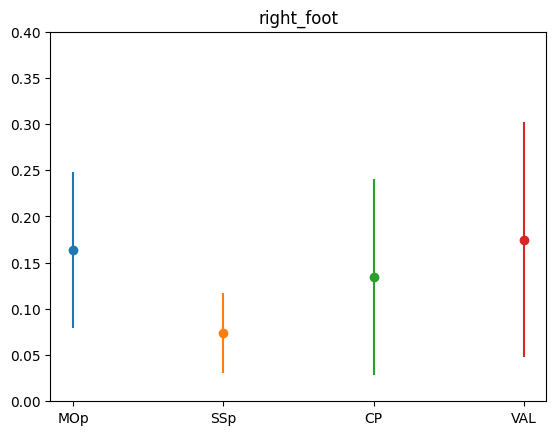

Dropped 38 trials 11.41


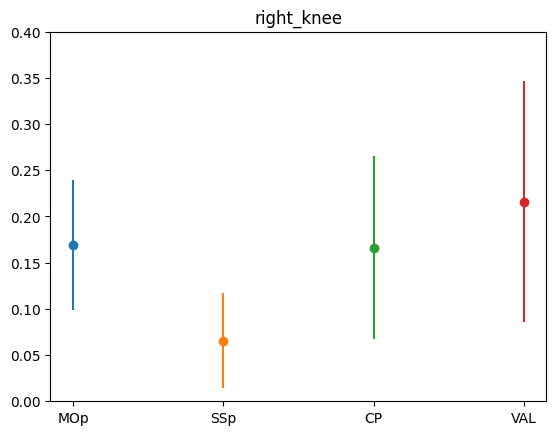

Dropped 16 trials 4.80


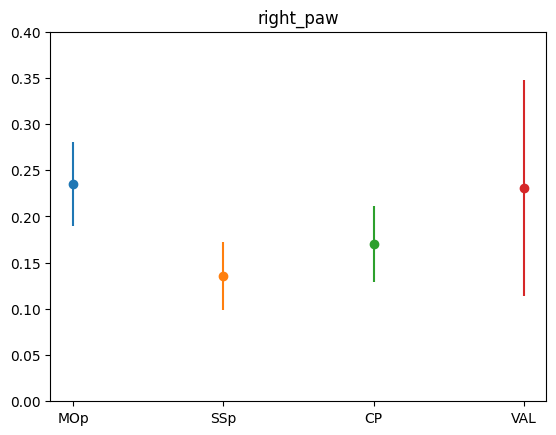

Dropped 17 trials 5.11


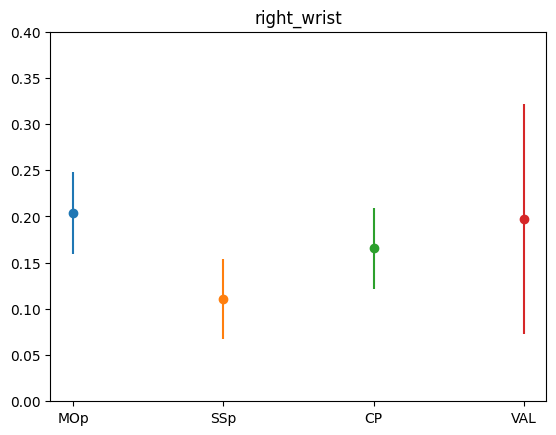

In [198]:
for field in ALL_BHV_FIELDS:
    df = concat_bhv(df__, col=[field])
    df = pyal.select_trials(df, df.trial_name == 'trial')
    df, powers = compute_power_in_td(df)
    df = add_power_metric_to_df(df)
    perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -200, rel_end=399)
    # perturb_td = perturb_td.sample(frac=1, random_state=42).reset_index(drop=True)
    mask = perturb_td["power_AUC"].apply(
        lambda x: x is not None and not np.any(np.isnan(x))
    )


    model = Ridge(alpha=100)
    fig, ax = plt.subplots()
    for area in ['MOp', 'SSp', 'CP', 'VAL']:
        X = np.stack(perturb_td[f'{area}_rates_pca'])[mask, :]
        y = np.stack(perturb_td.power_AUC.values[mask])
        n_trials, n_times, n_comp = X.shape
        

        r2s = cross_val_score(model, X.reshape(-1, n_times * (n_comp)), y, cv=5, scoring=decode.get_custom_scorer())
        ax.errorbar(x=area, y=r2s.mean(), yerr=r2s.std(), fmt='o')
    ax.set_ylim(0, 0.4)
    ax.set_title(field)
    plt.show()


## Clean

In [306]:
df = dt.add_bhv(df__, bhv_fields=['left_paw', 'right_paw'])
df = dt.concat_previous_intertrial_signal(df, 'MOp_rates_pca')
df = dt.concat_previous_intertrial_signal(df, 'SSp_rates_pca')

df = dt.concat_previous_intertrial_signal(df, 'CP_rates_pca')

df = dt.concat_previous_intertrial_signal(df, 'VAL_rates_pca')

df = dt.concat_previous_intertrial_signal(df, 'bhv', features=[2, 5])

df = dt.add_concat_perturb_time(df)
df = dt.add_concat_trial_start(df)

In [307]:
df_tr = pyal.select_trials(df, df.trial_name == 'trial')
df_tr = kin.compute_power_in_bhv_concat_td(df_tr)

Skipped 37 trials 11.11


In [308]:
mask = df_tr["concat_trial_start"].apply(
    lambda x: x > 101
)
df_tr = df_tr.loc[mask]

In [309]:
df_tr = kin.add_power_metric_to_td(df_tr)

In [310]:
mask = df_tr["disturb_score"].apply(
    lambda x: not np.any(np.isnan(x))
)

df_tr = df_tr.loc[mask]

In [311]:
len(df_tr)

198

(array([  1.,   0.,   0.,   0.,   0.,   1.,   2.,   8.,  18., 168.]),
 array([-317.42041478, -285.07748057, -252.73454636, -220.39161216,
        -188.04867795, -155.70574375, -123.36280954,  -91.01987533,
         -58.67694113,  -26.33400692,    6.00892728]),
 <BarContainer object of 10 artists>)

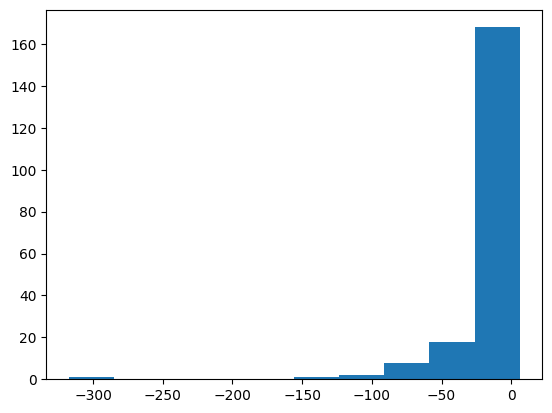

In [251]:
plt.hist(df_tr.disturb_score.values)

In [179]:
len(df_tr)

222

In [16]:
bhv_arr = df_tr.bhv_concat.values[tr]
perturb_idx = df_tr.concat_perturb_time.values[tr]

In [124]:
def morlet_tfr_power(
    x: np.ndarray,
    fs: float,
    freqs: np.ndarray,
    n_cycles: float = 3.0,
    use_fft: bool = True,
) -> np.ndarray:
    """
    Complex Morlet wavelet power (|conv|^2).

    Parameters
    ----------
    x : (T,) array
        1D signal.
    fs : float
        Sampling rate in Hz.
    freqs : (F,) array
        Frequencies of interest in Hz.
    n_cycles : float
        Number of cycles per wavelet. Smaller -> better time resolution, worse freq resolution.
        For maximal time resolution at ~7–8 Hz, try 2–3.
    use_fft : bool
        Use FFT convolution (recommended).

    Returns
    -------
    power : (F, T) array
        Time-frequency power.
    """
    x = np.asarray(x, dtype=float)
    T = x.size
    freqs = np.asarray(freqs, dtype=float)

    power = np.empty((freqs.size, T), dtype=float)

    # zero-mean to reduce leakage from DC offset
    x0 = x - np.mean(x)

    for i, f in enumerate(freqs):
        # Morlet definition: exp(2πift) * exp(-t^2/(2σ_t^2))
        sigma_t = n_cycles / (2 * np.pi * f)  # seconds
        # wavelet support: ±4σ_t is usually sufficient
        t_max = 4 * sigma_t
        t = np.arange(-t_max, t_max, 1 / fs)
        wavelet = np.exp(2j * np.pi * f * t) * np.exp(-(t**2) / (2 * sigma_t**2))

        # normalise to unit energy so power is comparable across frequencies
        wavelet /= np.sqrt(np.sum(np.abs(wavelet) ** 2))

        if use_fft:
            n_conv = T + wavelet.size - 1
            n_fft = 1 << int(np.ceil(np.log2(n_conv)))
            X = np.fft.fft(x0, n_fft)
            print(X.shape)
            W = np.fft.fft(wavelet, n_fft)
            print(W.shape)
            conv = np.fft.ifft(X * W)[:n_conv]
            print(conv.shape)
        else:
            conv = np.convolve(x0, wavelet, mode="full")
        
        plt.plot(wavelet)

        # crop to original length (centre)
        start = (wavelet.size - 1) // 2
        conv = conv[start:start + T]

        power[i] = np.abs(conv) ** 2

    return power


def plot_tfr(power, freqs, fs, t0_s=0.0, vmin=None, vmax=None, log_power=True):
    """
    Plot time-frequency power.
    power: (F, T) array
    freqs: (F,) Hz
    fs: sampling rate (Hz)
    t0_s: start time offset in seconds for x-axis
    log_power: use 10*log10(power) for readability
    """
    power = np.asarray(power)
    freqs = np.asarray(freqs)

    T = power.shape[1]
    times = t0_s + np.arange(T) / fs

    Z = 10 * np.log10(power + 1e-12) if log_power else power

    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(
        Z,
        aspect="auto",
        origin="lower",
        extent=[times[0], times[-1], freqs[0], freqs[-1]],
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
    )
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency (Hz)")
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Power (dB)" if log_power else "Power")
    return fig, ax

# Example:
# fig, ax = plot_tfr(power, freqs, fs, t0_s=-2.0)
# ax.axvline(perturb_time_s, linestyle="--")  # optional
# plt.show()


In [54]:
freqs = np.linspace(1, 20, 200)           # dense grid
power = morlet_tfr_power(bhv_arr[:, 0], 100, freqs, n_cycles=2.5)

In [59]:
power.shape

(200, 1100)

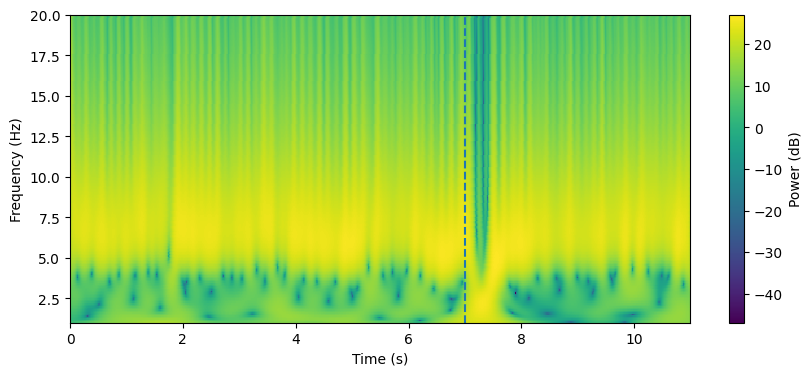

In [61]:
fig, ax = plot_tfr(power, freqs, 100)
ax.axvline(7, linestyle="--")  # optional
plt.show()

In [48]:
kin.compute_peak_freq_pre_perturb(bhv_arr, perturb_idx, nperseg=1000, noverlap=0.9)

/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/scipy/signal/_spectral_py.py:600: UserWarning: nperseg = 1000 is greater than input length  = 700, using nperseg = 700
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


array([7.42857143, 7.42857143])

In [63]:
filt_data = dsp.sos_bandpass_filter(bhv_arr[:, 0], fs=100, freqs=(6.5, 8.5))

In [130]:
mlt_power_ = kin.morlet_tfr_power_multi(bhv_arr[:, 0], 100, 7.42)

In [132]:
mlt_power_ = kin.compute_morlet_power(bhv_arr[:, 0], 100, 7.42)

(2048,)
(2048,)
(1151,)


/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


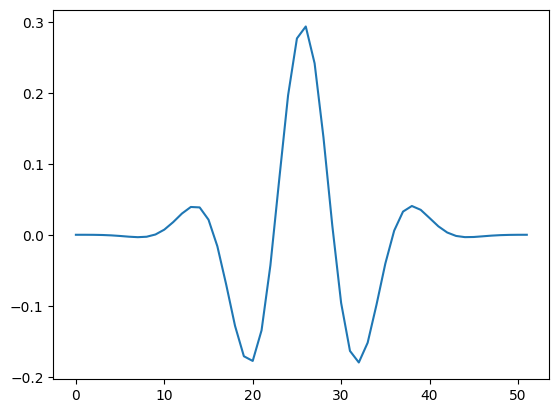

In [125]:
mlt_power = morlet_tfr_power(bhv_arr[:, 0], 100, [7.42])

In [68]:
mlt_power.shape

(1, 1100)

In [104]:
mlt_power.shape

(1100, 1, 1)

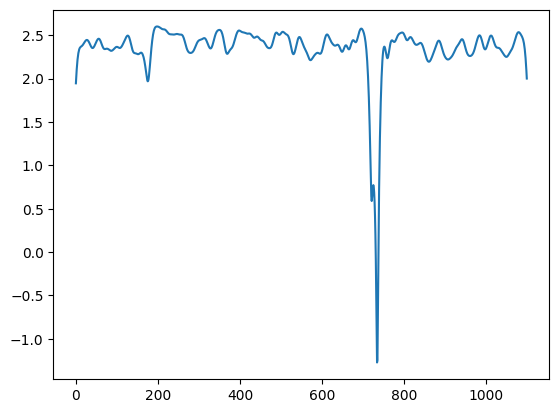

In [133]:
plt.plot(np.log10(np.squeeze(mlt_power_)))

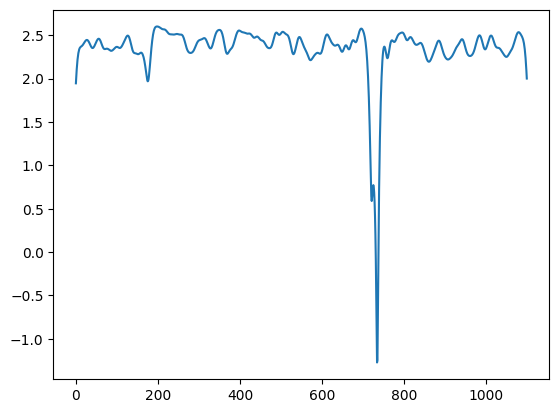

In [112]:
plt.plot(np.log10(mlt_power.T))

In [42]:
analytic = scipy.signal.hilbert(filt_data)
phase = np.angle(analytic)

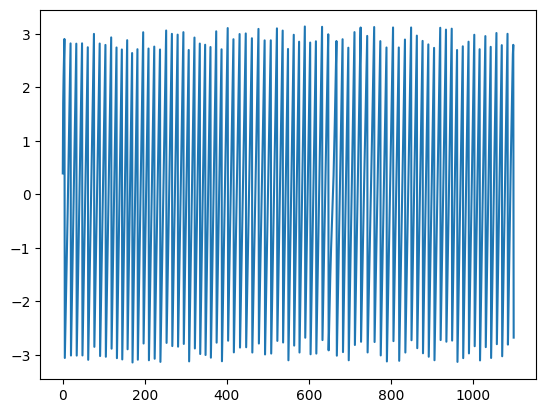

In [32]:
plt.plot(phase)

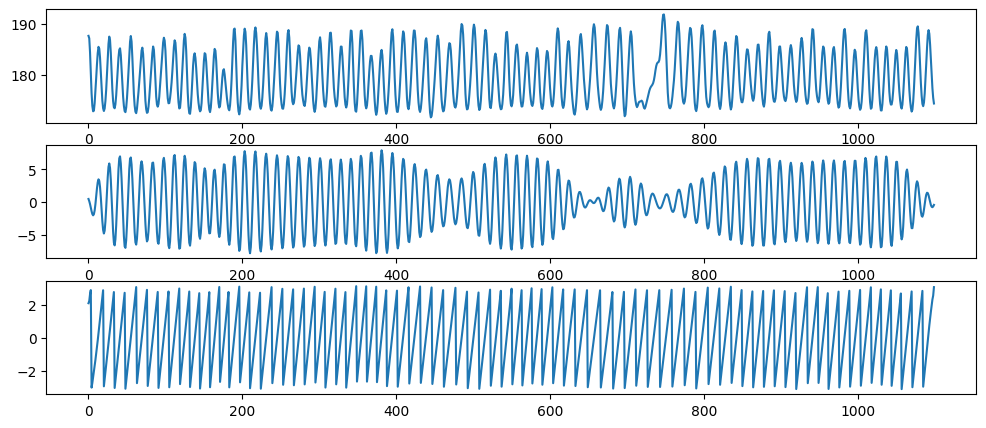

In [64]:
fig, ax = plt.subplots(3, 1, figsize=(12, 5))
ax[0].plot(bhv_arr[:, 0])
ax[1].plot(filt_data)
ax[2].plot(phase)

In [195]:
np.random.randint(0, 10, 5)

array([7, 9, 5, 4, 0])

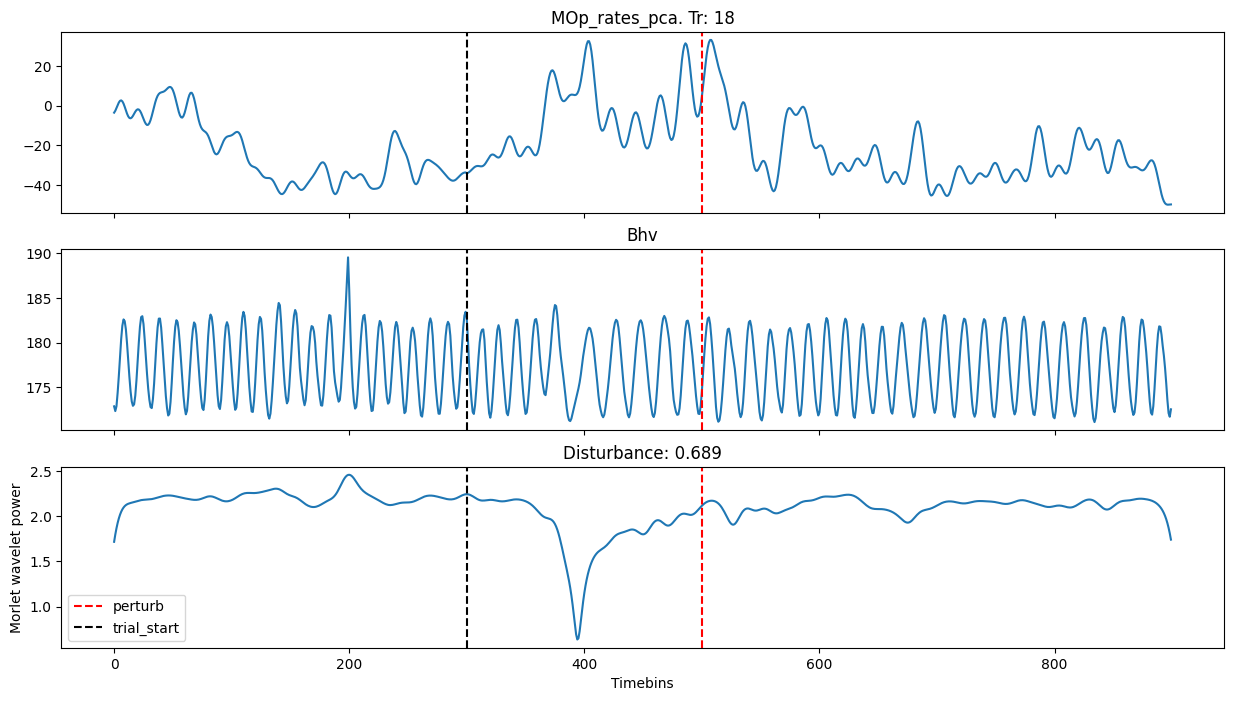

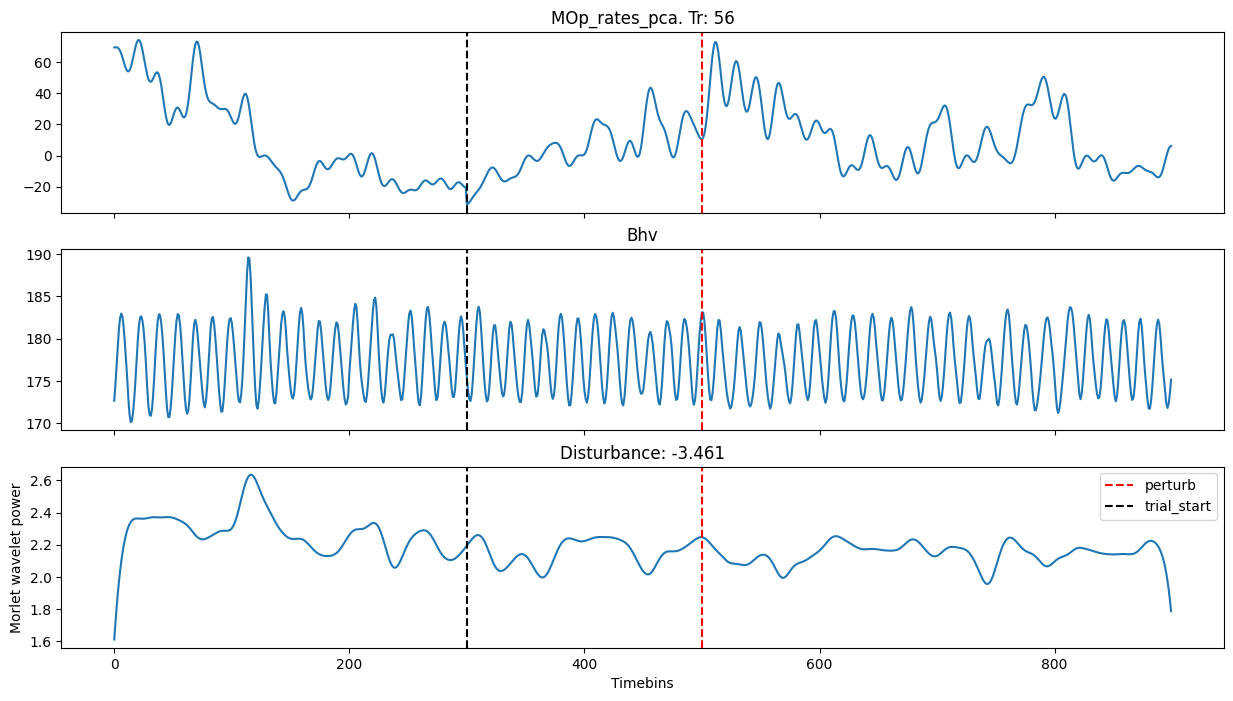

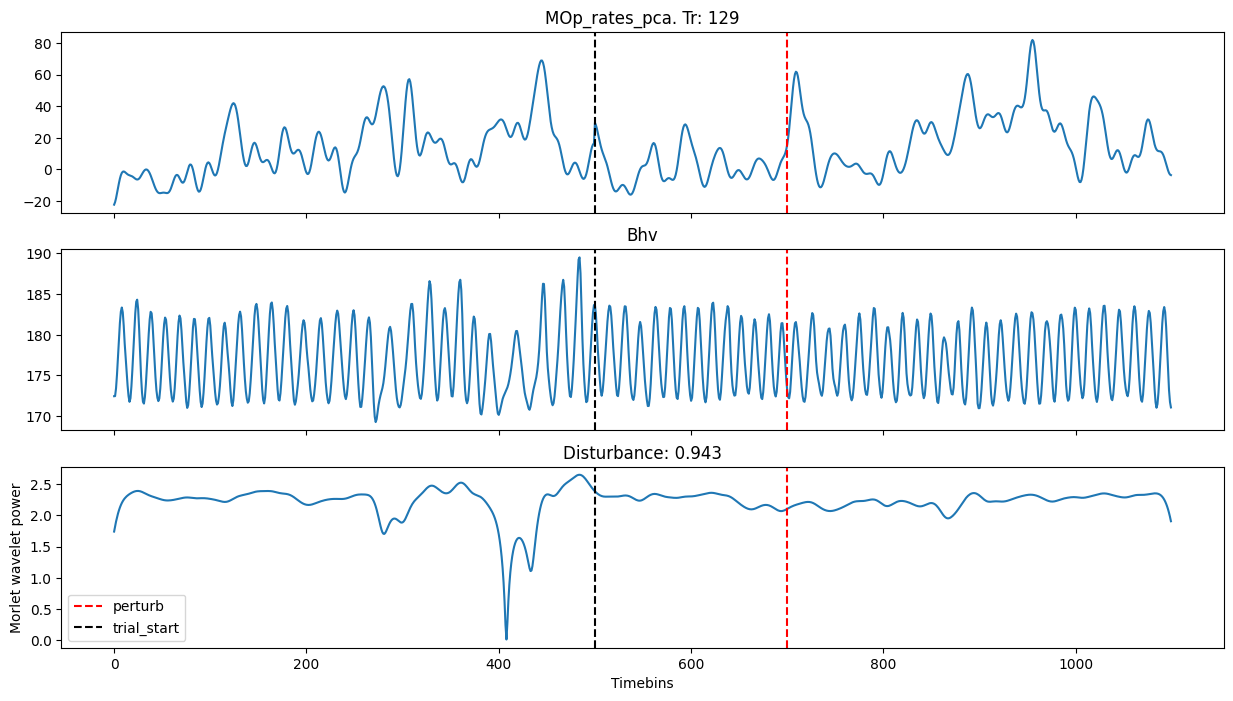

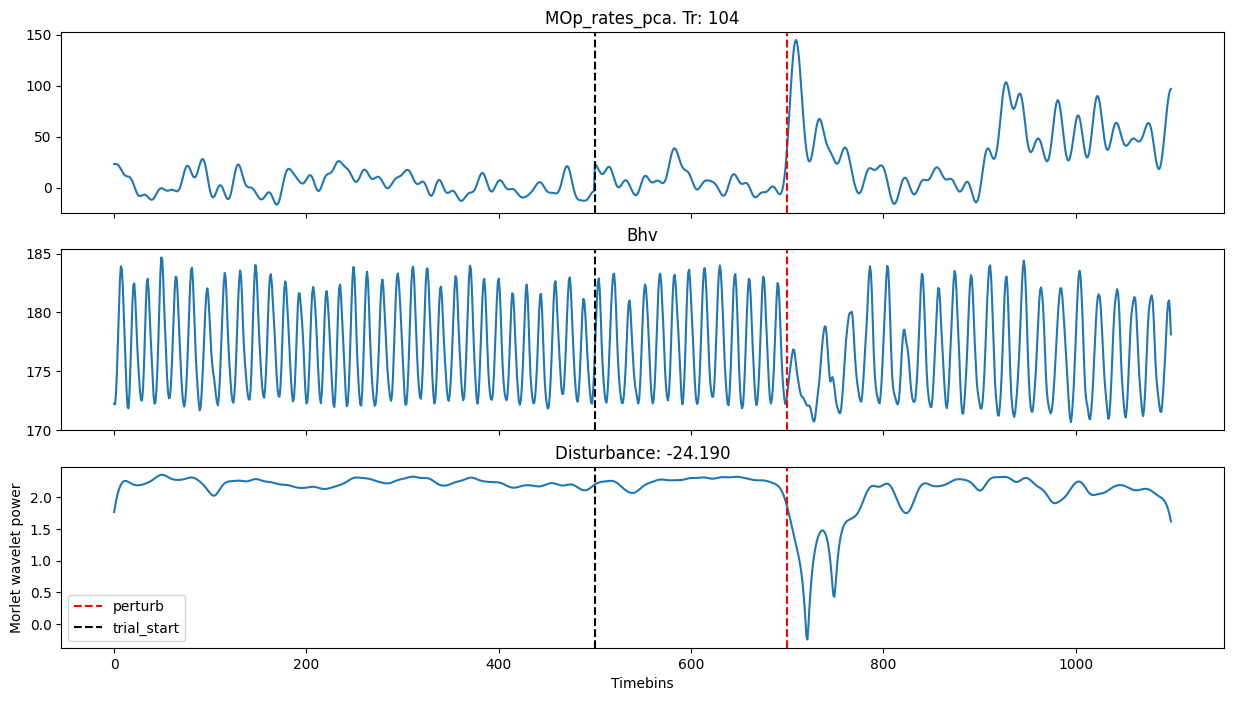

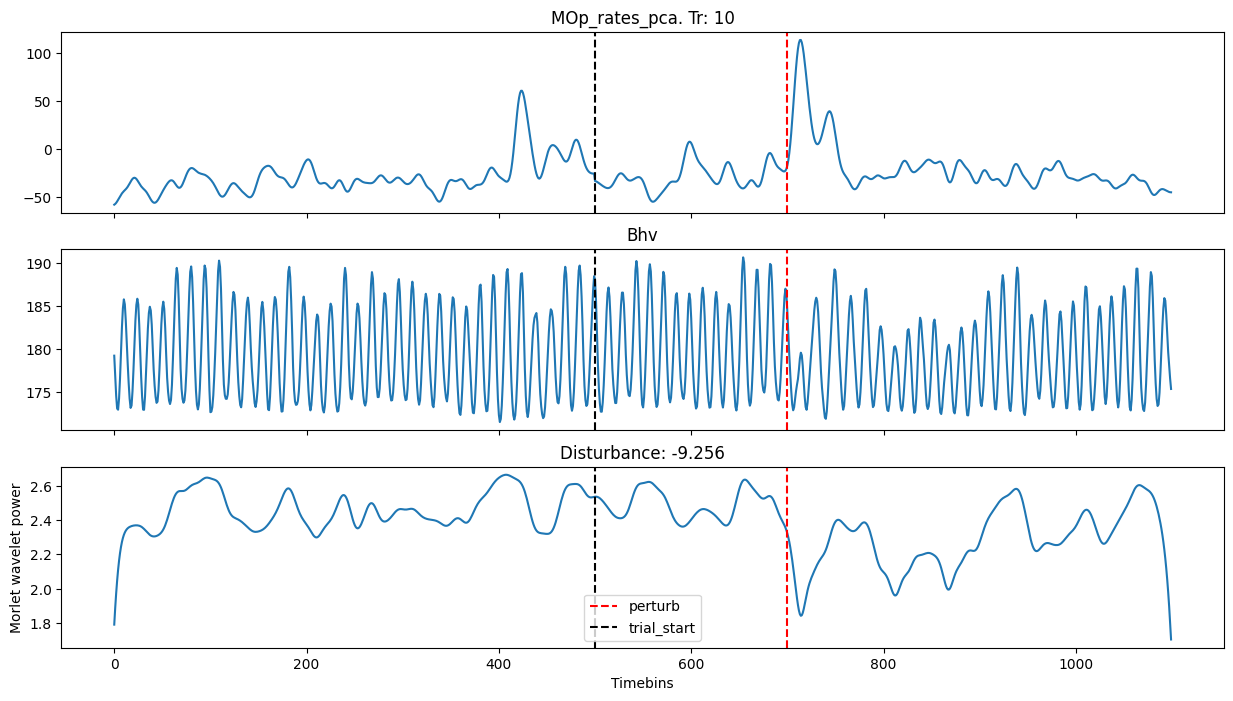

In [201]:

for tr in np.random.randint(0, 150, 5):

    fig, axs = plt.subplots(3, 1, figsize=(15,8), sharex='all')
    ax, ax1, ax2 = axs
    ax.plot(df_tr.MOp_rates_pca_concat.values[tr][:, :1])
    ax.set_title(f'MOp_rates_pca. Tr: {tr}')
    ax1.plot(df_tr.bhv_concat.values[tr][:, 0])
    ax1.set_title('Bhv')

    ax2.plot(df_tr.power.values[tr][:, 0])
    # ax2.plot(np.log10(mlt_power.T))
    # ax2.plot(filt_data)
    ax2.set_xlabel('Timebins')
    ax2.set_ylabel('Morlet wavelet power')

    ax2.set_title(f'Disturbance: {df_tr.disturb_score.values[tr]:.3f}')

    # ax3.plot(df_tr.phase.values[tr][:, 0])
    for ax in axs:
        ax.axvline(df_tr.concat_perturb_time.values[tr], color='red',linestyle='dashed', 
                label='perturb')
        ax.axvline(df_tr.concat_trial_start.values[tr], color='k',linestyle='dashed', label='trial_start')
    ax.legend()
# ax.set_xlim(600, 800)

In [164]:
power = df_tr.power.values[tr]

In [168]:
power_ = (power - power[100:475].mean(0)) / power[100:475].std(0)

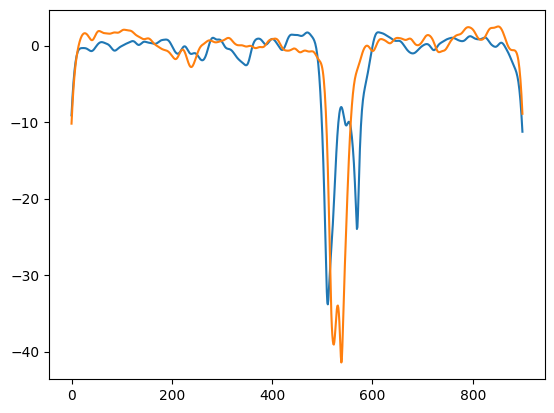

In [169]:
plt.plot(power_)

In [ ]:
# df = concat_previous_intertrial_signal(df, 'MOp_rates_pca')
# df = concat_previous_intertrial_signal(df, 'bhv', features=[2, 5])
# df = add_concat_perturb_time(df)
# df = pyal.select_trials(df, df.trial_name == 'trial')
# df = compute_power_in_td(df

In [312]:
areas = ['MOp', 'SSp', 'CP', 'VAL']
for area in areas:
    df_tr[f"{area}_rates_pca_concat"] = df_tr.apply(
        lambda row: row[f"{area}_rates_pca_concat"][row["concat_perturb_time"] - 500:, :],
        axis=1
    )

# df_tr[f"bhv_concat"] = df_tr.apply(
#         lambda row: row[f"{area}bhv_concat"][row["concat_perturb_time"] - 500:, :],
#         axis=1
#     )

In [294]:
df_tr.MOp_rates_pca_concat.values[4].shape

(50, 178)

In [301]:
df_tr.bhv_concat.values[3][:, 0].shape

(1100,)

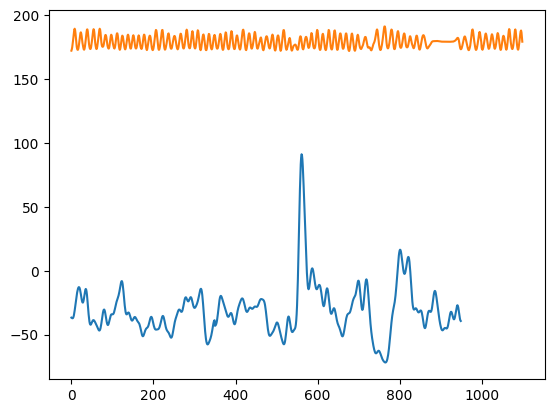

In [300]:
plt.plot(df_tr.MOp_rates_pca_concat.values[3][:, 0])
plt.plot(df_tr.bhv_concat.values[3][:, 0])

In [297]:
df_tr.concat_perturb_time.values[3]

700

In [278]:
df_tr[f"bhv_concat"] = df_tr.apply(
        lambda row: row[f"bhv_concat"][row["concat_perturb_time"] - 500:, :],
        axis=1
    )

In [316]:
scores_paw = {}
for area in areas:
    scores_, times = decode.decoding_moving_window_no_time_concat(
        Ridge(alpha=100),
        X=np.stack(df_tr[f'{area}_rates_pca_concat']),
        y=np.roll(np.stack(df_tr.disturb_score.values), 1),
        window_length_bin=200,
        step_bin=5,
        cv=5
    )
    scores_paw[area] = scores_

  0%|          | 0/141 [00:00<?, ?it/s]

100%|██████████| 141/141 [00:19<00:00,  7.10it/s]


In [304]:
scores_, times = decode.decoding_moving_window_no_time_concat(
        Ridge(alpha=100),
        X=np.stack(df_tr[f'bhv_concat']),
        y=np.stack(df_tr.disturb_score.values),
        window_length_bin=200,
        step_bin=5,
        cv=5
    )
scores_paw['bhv'] = scores_

ValueError: all input arrays must have the same shape

In [ ]:
areas = ['MOp', 'SSp', 'CP', 'VAL']

['MOp', 'SSp', 'CP', 'VAL', 'bhv']

In [231]:
len(df_tr)

198

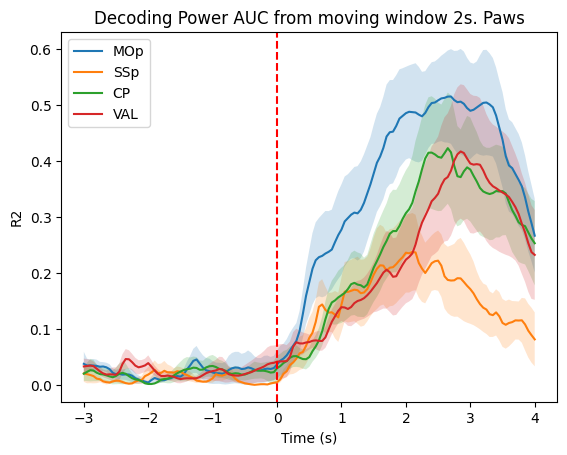

In [303]:
fig, ax = plt.subplots()
# st
for area in areas:
    vizutils.shaded_errorbar(ax, times-5, scores_paw[area], label=area, errorStat=scipy.stats.sem)
ax.axvline(0, color='r', linestyle='dashed')
ax.set_xlabel('Time (s)')
ax.set_ylabel('R2')
ax.set_title('Decoding Power AUC from moving window 2s. Paws')
# ax.set_ylim(0, 0.25)
ax.legend()

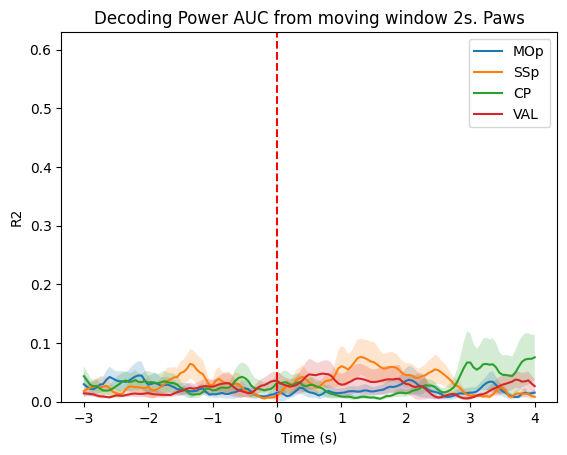

In [319]:
fig, ax = plt.subplots()
# st
for area in areas:
    vizutils.shaded_errorbar(ax, times-5, scores_paw[area], label=area, errorStat=scipy.stats.sem)
ax.axvline(0, color='r', linestyle='dashed')
ax.set_xlabel('Time (s)')
ax.set_ylabel('R2')
ax.set_title('Decoding Power AUC from moving window 2s. Paws')
ax.set_ylim(0, 0.63)
ax.legend()

In [237]:
y = np.stack(df_tr.disturb_score.values)

In [239]:
y

array([-8.82993690e-01, -1.21358406e+00, -1.28899196e+00, -5.43108694e+00,
        5.72346875e-01, -6.74032253e-02, -1.52513461e+00, -1.76284995e+00,
       -1.05952438e+00, -1.80182750e-01, -9.75453590e-01, -1.57944481e-01,
       -1.95806487e-01, -2.17392465e-01, -2.30990137e+00, -2.82050747e+00,
       -1.93401624e+00, -3.89787233e+00,  6.47743659e-01, -1.12139982e+00,
       -2.54451927e-02, -1.16520675e+01, -3.14704081e-01,  3.72849711e-01,
       -2.48501658e-01, -1.68680619e+00, -1.85191117e-01, -1.81952875e-01,
       -1.31597489e+00, -3.85287458e+00, -8.95654910e-02, -2.34725093e-01,
       -5.56277426e+00, -1.04493650e+00, -2.55807178e+00, -4.96011720e-01,
       -3.09905831e-01, -1.62095018e+00, -1.50117405e+00, -1.16648123e+00,
       -7.78869032e+00, -8.34965424e-01, -4.33622589e+00, -6.30782335e+00,
        2.42190715e-01,  1.46418593e-01,  1.76558699e+00, -2.37158895e+00,
        3.23282931e-01, -3.14664402e-01, -3.51813893e-01,  2.14555384e-02,
       -2.43554583e+00, -

In [238]:
np.roll(y, 1)

array([-2.53199631e+00, -8.82993690e-01, -1.21358406e+00, -1.28899196e+00,
       -5.43108694e+00,  5.72346875e-01, -6.74032253e-02, -1.52513461e+00,
       -1.76284995e+00, -1.05952438e+00, -1.80182750e-01, -9.75453590e-01,
       -1.57944481e-01, -1.95806487e-01, -2.17392465e-01, -2.30990137e+00,
       -2.82050747e+00, -1.93401624e+00, -3.89787233e+00,  6.47743659e-01,
       -1.12139982e+00, -2.54451927e-02, -1.16520675e+01, -3.14704081e-01,
        3.72849711e-01, -2.48501658e-01, -1.68680619e+00, -1.85191117e-01,
       -1.81952875e-01, -1.31597489e+00, -3.85287458e+00, -8.95654910e-02,
       -2.34725093e-01, -5.56277426e+00, -1.04493650e+00, -2.55807178e+00,
       -4.96011720e-01, -3.09905831e-01, -1.62095018e+00, -1.50117405e+00,
       -1.16648123e+00, -7.78869032e+00, -8.34965424e-01, -4.33622589e+00,
       -6.30782335e+00,  2.42190715e-01,  1.46418593e-01,  1.76558699e+00,
       -2.37158895e+00,  3.23282931e-01, -3.14664402e-01, -3.51813893e-01,
        2.14555384e-02, -

In [240]:
df_for_rolling = df_tr[1:]

197

In [243]:
scores_paw_rolled = {}
for area in ['MOp']:
    scores_, times = decode.decoding_moving_window_no_time_concat(
        Ridge(alpha=100),
        X=np.stack(df_for_rolling[f'{area}_rates_pca_concat']),
        y=np.roll(np.stack(df_tr.disturb_score.values), 1)[1:],
        window_length_bin=200,
        step_bin=5,
        cv=4
    )
    scores_paw_rolled[area] = scores_

  0%|          | 0/141 [00:00<?, ?it/s]

100%|██████████| 141/141 [00:15<00:00,  8.93it/s]


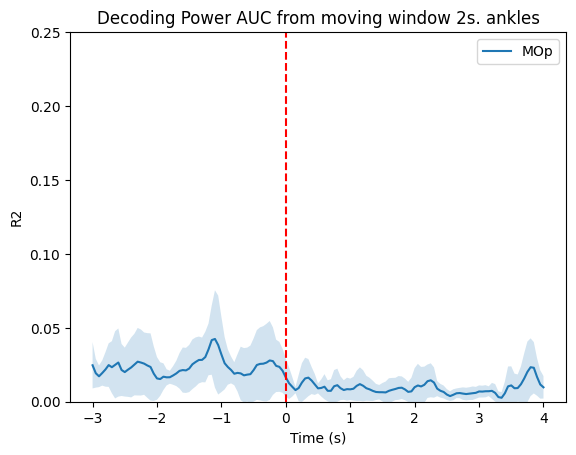

In [244]:
fig, ax = plt.subplots()
# st
for area in ['MOp']:
    vizutils.shaded_errorbar(ax, times-5, scores_paw_rolled[area], label=area)
ax.axvline(0, color='r', linestyle='dashed')
ax.set_xlabel('Time (s)')
ax.set_ylabel('R2')
ax.set_title('Decoding Power AUC from moving window 2s. ankles')
ax.set_ylim(0, 0.25)
ax.legend()

# Decoding disturbance

In [4]:
data_dir='/data/bnd-data/raw/'
session='M061_2025_03_06_14_00'

In [5]:
df_ = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)
df_ = dsp.preprocess(
    df_,
    only_trials=False,
    combine_time_bins=False, 
    # repair_time_varying_fields=['MotSen1_X', 'MotSen1_Y']
)

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)


In [5]:
df__ = dt.add_pca_df(df_)

In [6]:
ALL_BHV_FIELDS = [
    "left_ankle",
    "left_elbow",
    "left_foot",
    "left_knee",
    "left_paw",
    "left_wrist",
    "right_ankle",
    "right_elbow",
    "right_foot",
    "right_knee",
    "right_paw",
    "right_wrist",
]
feature_dims = np.arange(start=2, stop=len(ALL_BHV_FIELDS)*3, step=3)


In [257]:
df = dt.add_bhv(df__, bhv_fields=ALL_BHV_FIELDS)
df = dt.concat_previous_intertrial_signal(df, 'MOp_rates_pca')
df = dt.concat_previous_intertrial_signal(df, 'SSp_rates_pca')
df = dt.concat_previous_intertrial_signal(df, 'CP_rates_pca')
df = dt.concat_previous_intertrial_signal(df, 'VAL_rates_pca')
df = dt.concat_previous_intertrial_signal(df, 'bhv', features=feature_dims)

# Compute metric
df = dt.add_concat_perturb_time(df)
df = dt.add_concat_trial_start(df)
df = kin.compute_power_in_bhv_concat_td(df)
df = kin.add_power_metric_to_td(df)

# Slice trials
df = dt.concat_previous_intertrial_signal(df, 'bhv')
df_tr = pyal.select_trials(df, df.trial_name == 'trial')

# # Drop short intertrials
mask = df_tr["concat_trial_start"].apply(
    lambda x: x > 101
)
df_tr = df_tr.loc[mask]
mask = df_tr["disturb_score"].apply(
    lambda x: not np.any(np.isnan(x))
)

df_tr = df_tr.loc[mask]

Skipped 71 trials 10.61


In [100]:
areas = ['MOp', 'SSp', 'CP', 'VAL']

In [65]:
len(df_tr)

0

In [216]:
df_tr_sliced = df_tr.copy()

for area in areas:
    col = f"{area}_rates_pca_concat"
    df_tr_sliced[col] = df_tr.apply(
        lambda row: row[col][row["concat_perturb_time"] - 500:, :],
        axis=1
    )

df_tr_sliced['bhv_concat'] = df_tr.apply(
    lambda row: row['bhv_concat'][row["concat_perturb_time"] - 500:, :],
    axis=1
)

In [102]:
scores_paw_100 = {}
# df_tr_sliced_ = df_tr_sliced.sample(frac=1, random_state=42).reset_index(drop=True)

for area in areas:
    scores_, times = decode.decoding_moving_window_no_time_concat(
        Ridge(alpha=100),
        X=np.stack(df_tr_sliced[f'{area}_rates_pca_concat']),
        y=np.stack(df_tr_sliced.disturb_score.values),
        window_length_bin=100,
        step_bin=5,
        cv=5
    )
    scores_paw_100[area] = scores_

  0%|          | 0/161 [00:00<?, ?it/s]

100%|██████████| 161/161 [00:26<00:00,  6.17it/s]


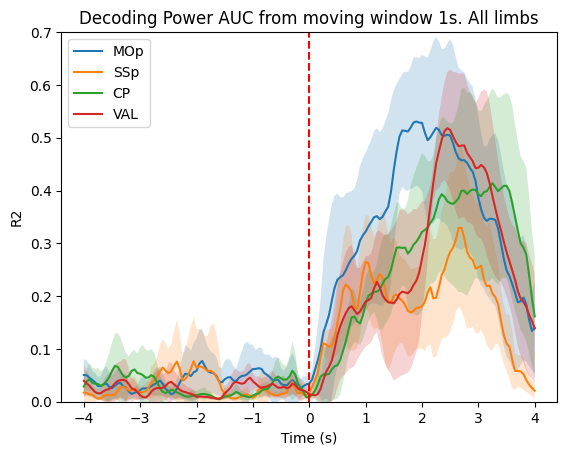

In [103]:
fig, ax = plt.subplots()
for area in areas:
    vizutils.shaded_errorbar(ax, times-5, scores_paw_100[area], label=area, errorStat=np.std)
ax.axvline(0, color='r', linestyle='dashed')
ax.set_xlabel('Time (s)')
ax.set_ylabel('R2')
ax.set_title('Decoding Power AUC from moving window 1s. All limbs')
ax.set_ylim(0, 0.7)
ax.legend()

In [166]:
# df_tr_sliced_ = df_tr_sliced.sample(frac=1, random_state=42).reset_index(drop=True)

scores, times = decode.decoding_moving_window_no_time_concat(
        Ridge(alpha=100),
        X=np.stack(df_tr_sliced[f'bhv_concat']),
        y=np.stack(df_tr_sliced.disturb_score.values),
        window_length_bin=20,
        step_bin=1,
        cv=5,
        min_time_bin=400,
        max_time_bin=600
    )

  0%|          | 0/181 [00:00<?, ?it/s]

100%|██████████| 181/181 [00:12<00:00, 14.11it/s]


In [107]:
df_tr_sliced[f'bhv_concat'].values[0].shape

(900, 36)

In [163]:
len(df_tr_sliced)

170

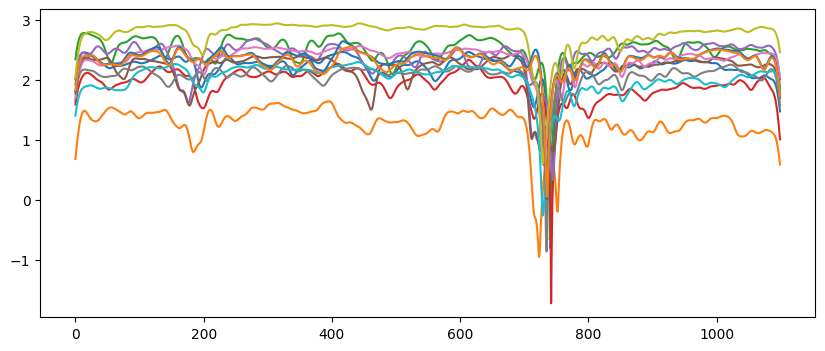

In [170]:
plt.figure(figsize=(10, 4))
plt.plot(df_tr.power.values[0])

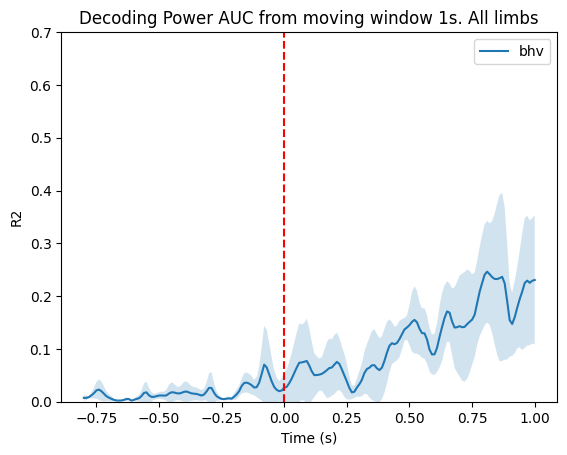

In [165]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, times-5, scores, label='bhv', errorStat=np.std)
ax.axvline(0, color='r', linestyle='dashed')
ax.set_xlabel('Time (s)')
ax.set_ylabel('R2')
ax.set_title('Decoding Power AUC from moving window 1s. All limbs')
ax.set_ylim(0, 0.7)
ax.legend()

In [223]:
col = "disturb_score"

df_sorted = df_tr_sliced.assign(
    _row_sum=df[col].apply(lambda x: np.nansum(x))
).sort_values(
    by="_row_sum", ascending=False
).drop(
    columns="_row_sum"
)

700

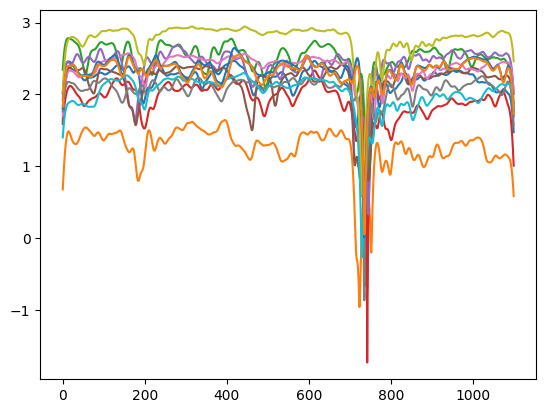

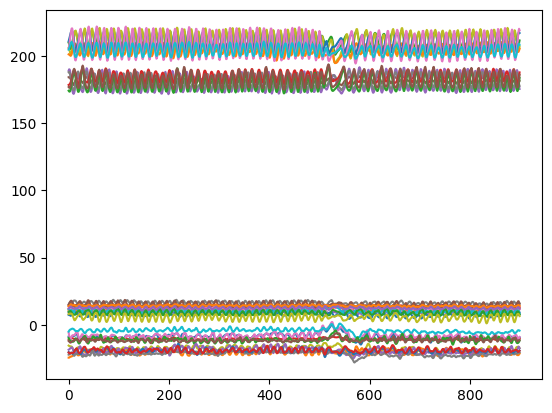

In [255]:
plt.plot(df_tr_sliced.power.values[0])
plt.figure()
plt.plot(df_tr_sliced.bhv_concat.values[0])
df_tr_sliced.concat_perturb_time.values[0]

In [241]:

scores_bhv, times = decode.decoding_moving_window_no_time_concat(
        Ridge(alpha=100),
        X=np.stack(df_sorted[f'bhv_concat'])[:136, :, :],
        y=np.stack(df_sorted.disturb_score.values)[:136, :],
        window_length_bin=20,
        step_bin=1,
        cv=5,
        min_time_bin=200,
        # max_time_bin=600
    )

# scores_ephys = {}
# for area in areas:
#     scores_, times = decode.decoding_moving_window_no_time_concat(
#         Ridge(alpha=100),
#         X=np.stack(df_sorted[f'{area}_rates_pca_concat'])[:100, :, :],
#         y=np.stack(df_sorted.disturb_score.values)[:100, :],
#         window_length_bin=20,
#         step_bin=1,
#         cv=5,
#         min_time_bin=300,
#     )
#     scores_ephys[area] = scores_

  0%|          | 3/681 [00:00<00:26, 25.51it/s]

100%|██████████| 681/681 [00:45<00:00, 15.02it/s]


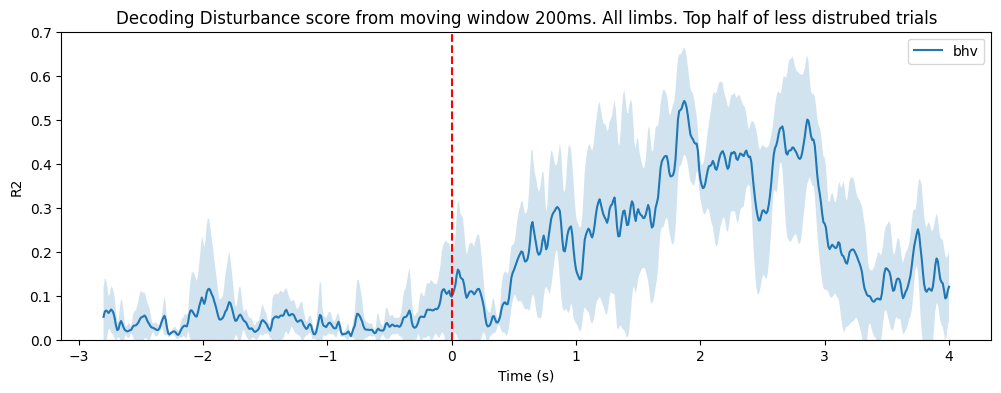

In [242]:
fig, ax = plt.subplots(figsize=(12, 4))
vizutils.shaded_errorbar(ax, times-5, scores_bhv, label='bhv', errorStat=np.std)
ax.axvline(0, color='r', linestyle='dashed')
ax.set_xlabel('Time (s)')
ax.set_ylabel('R2')
ax.set_title('Decoding Disturbance score from moving window 200ms. All limbs. Top half of less distrubed trials')
ax.set_ylim(0, 0.7)
ax.legend()

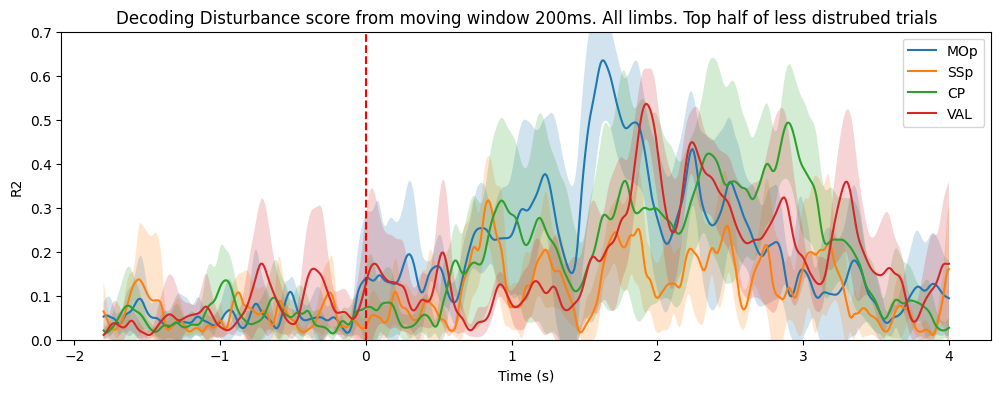

In [209]:
fig, ax = plt.subplots(figsize=(12, 4))
for area in areas:
    vizutils.shaded_errorbar(ax, times-5, scores_ephys[area], label=area, errorStat=np.std)
ax.axvline(0, color='r', linestyle='dashed')
ax.set_xlabel('Time (s)')
ax.set_ylabel('R2')
ax.set_title('Decoding Disturbance score from moving window 200ms. All limbs. Top half of less distrubed trials')
ax.set_ylim(0, 0.7)
ax.legend()

## Understand the metric

In [5]:
df__ = dt.add_pca_df(df_)

In [6]:
ALL_BHV_FIELDS = [
    "left_ankle",
    "left_elbow",
    "left_foot",
    "left_knee",
    "left_paw",
    "left_wrist",
    "right_ankle",
    "right_elbow",
    "right_foot",
    "right_knee",
    "right_paw",
    "right_wrist",
]
feature_dims = np.arange(start=2, stop=len(ALL_BHV_FIELDS)*3, step=3)


Skipped 71 trials 10.61
d: 1.194
Bimodal: False
Thresh: 1.09
Dropped 17 of 333 rows (5.11%).


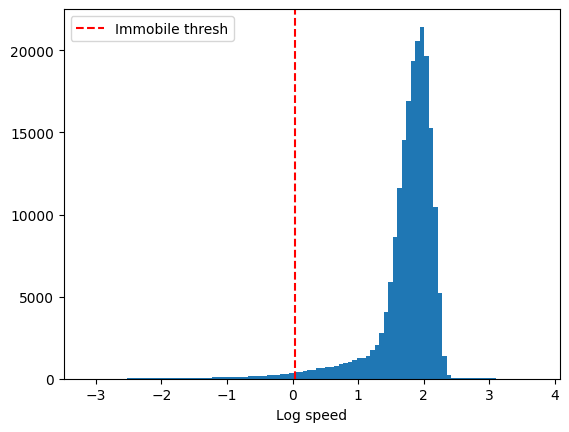

In [131]:
df = dt.add_bhv(df__, bhv_fields=ALL_BHV_FIELDS)
df = dt.concat_previous_intertrial_signal(df, 'MOp_rates_pca')
df = dt.concat_previous_intertrial_signal(df, 'SSp_rates_pca')
df = dt.concat_previous_intertrial_signal(df, 'CP_rates_pca')
df = dt.concat_previous_intertrial_signal(df, 'VAL_rates_pca')
df = dt.concat_previous_intertrial_signal(df, 'bhv', features=feature_dims)

# Compute metric
df = dt.add_concat_perturb_time(df)
df = dt.add_concat_trial_start(df)
df = kin.compute_power_in_bhv_concat_td(df)
df = kin.add_power_metric_to_td(df)

# Select trials and drop nans
df = dt.concat_previous_intertrial_signal(df, 'bhv')
df_tr = pyal.select_trials(df, df.trial_name == 'trial')
df_tr = kin.drop_immobile_trials_from_td(df_tr, p=2, win=10)
mask = df_tr["disturb_score"].apply(
    lambda x: not np.any(np.isnan(x))
)
df_tr = df_tr.loc[mask]

# Slice fields
df_tr_sliced = df_tr.copy()
fields = [
    'power',
    'phases', 
    'MOp_rates_pca_concat',
    'SSp_rates_pca_concat',
    'VAL_rates_pca_concat',
    'CP_rates_pca_concat',
    'bhv_concat'
    ]
for field in fields:
    df_tr_sliced[field] = df_tr.apply(
        lambda row: row[field][row["concat_perturb_time"] - 300:row["concat_perturb_time"] + 400, :],
        axis=1
    )

# Add instantaneous phase
df_tr_sliced["perturb_phase"] = df_tr_sliced["phases"].apply(lambda a: a[300, :])

col = "disturb_score"
df_sorted = df_tr_sliced.assign(
    _row_sum=df_tr_sliced[col].apply(lambda x: np.nansum(x))
).sort_values(
    by="_row_sum", ascending=True
).reset_index()


In [ ]:
for tr in np.arange(180, 221, step=10):
    # for tr in trials_200:
    fig, axs = plt.subplots(df_sorted.disturb_score.values[tr].shape[0], 2, figsize=(8, 16), 
                            sharex='all', sharey='col')
    print(tr)
    for idx in range(df_sorted.disturb_score.values[tr].shape[0]):
        axs[idx][1].plot(df_sorted.bhv_concat.values[tr][:, feature_dims[idx]])
        axs[idx][0].set_title(f'Power. Disturb_score: {df_sorted.disturb_score.values[tr][idx]:.3f}')
        axs[idx][0].plot(df_sorted.power.values[tr][:, idx])
        axs[idx][0].axvline(300, color='red')
        # axs[idx].set_title(field)
    # axs[-1].set_title(f'Bhv concant. Sol dir: {df_tr_sliced.values_Sol_direction[tr]}. Sol dur: {df_tr_sliced.values_Sol_duration[tr]}')
    plt.tight_layout()
    plt.show()


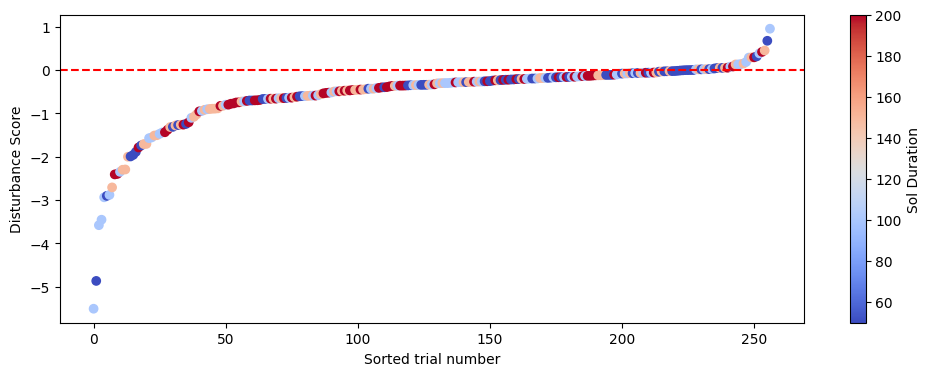

In [122]:
mean_disturb = np.stack(df_sorted.disturb_score.values).mean(-1)
fig, ax = plt.subplots(figsize=(12, 4))
# vizutils.shaded_errorbar(ax, df_sorted.index, mean_disturb)
scatter = ax.scatter(df_sorted.index, mean_disturb, c=df_sorted['values_Sol_duration'], cmap='coolwarm')
ax.axhline(0, color='r', linestyle='dashed')
ax.set_ylabel('Disturbance Score')
ax.set_xlabel('Sorted trial number')
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('Sol Duration')

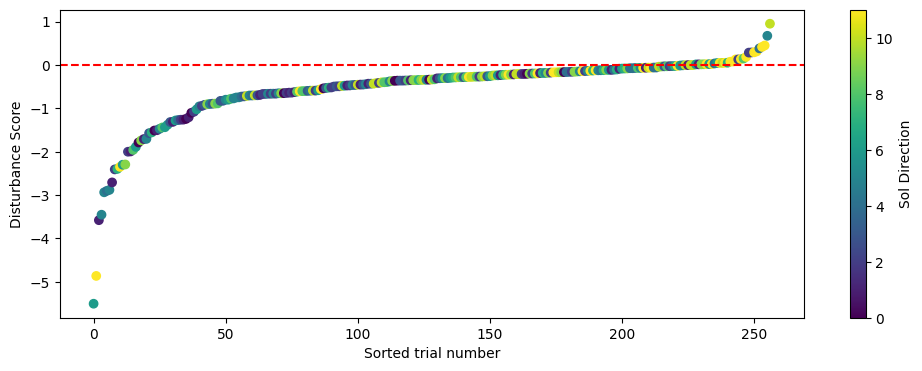

In [124]:
mean_disturb = np.stack(df_sorted.disturb_score.values).mean(-1)
fig, ax = plt.subplots(figsize=(12, 4))
# vizutils.shaded_errorbar(ax, df_sorted.index, mean_disturb)
scatter = ax.scatter(df_sorted.index, mean_disturb, c=df_sorted['values_Sol_direction'], cmap='viridis')
ax.axhline(0, color='r', linestyle='dashed')
ax.set_ylabel('Disturbance Score')
ax.set_xlabel('Sorted trial number')
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('Sol Direction')

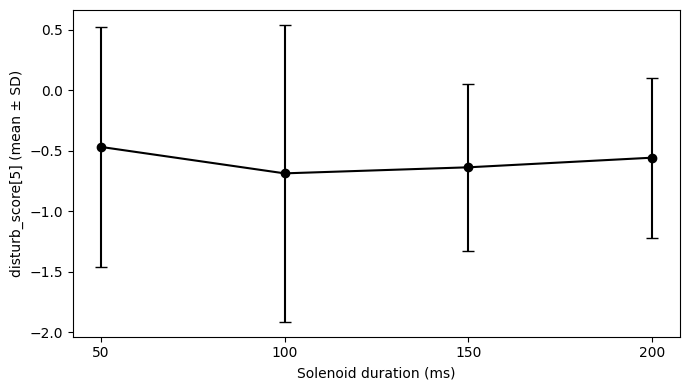

In [113]:
k = 5  # which disturb_score entry (0..9)

dfp = df_sorted.copy()
dfp = dfp.iloc[:]
dfp["values_Sol_duration"] = pd.to_numeric(dfp["values_Sol_duration"], errors="coerce")
dfp["disturb_k"] = dfp["disturb_score"].apply(lambda a: float(np.asarray(a)[k]))
dfp = dfp.dropna(subset=["values_Sol_duration", "disturb_k"])

cats = sorted(dfp["values_Sol_duration"].unique())
cat_to_x = {c: i for i, c in enumerate(cats)}

x = dfp["values_Sol_duration"].map(cat_to_x).to_numpy()
y = dfp["disturb_k"].to_numpy()

plt.figure(figsize=(7, 4))
# plt.scatter(x, y, alpha=0.6)

# mean ± std per category, connected by lines
g = dfp.groupby("values_Sol_duration")["disturb_k"]
means = g.mean().reindex(cats)
stds  = g.std(ddof=1).reindex(cats)

mx = np.array([cat_to_x[c] for c in cats])
my = means.to_numpy()
sy = stds.to_numpy()

plt.errorbar(mx, my, yerr=sy, fmt="o-", capsize=4, color='k')  # line + std bars

plt.xticks(mx, [str(int(c)) for c in cats])
plt.xlabel("Solenoid duration (ms)")
plt.ylabel(f"disturb_score[{k}] (mean ± SD)")
plt.tight_layout()
plt.show()


## Statistical effects of gait cycle, solenoid position, and solenoid opening

In [11]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [132]:
df_design = df_sorted.copy()
df_design = df_design.iloc[:175]
df_design['disturb_sum'] = df_design['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))
for idx in range(df_design.perturb_phase.values[0].shape[0]):
    df_design[f'perturb_phase_{idx}_sin'] = np.sin(np.stack(df_design.perturb_phase.values)[:, idx])
    df_design[f'perturb_phase_{idx}_cos'] = np.cos(np.stack(df_design.perturb_phase.values)[:, idx])
    df_design[f'perturb_phase_{idx}'] = np.stack(df_design.perturb_phase.values)[:, idx]

### Direction

                            OLS Regression Results                            
Dep. Variable:            disturb_sum   R-squared:                       0.111
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     1.858
Date:                Tue, 27 Jan 2026   Prob (F-statistic):             0.0485
Time:                        15:59:05   Log-Likelihood:                -194.37
No. Observations:                 175   AIC:                             412.7
Df Residuals:                     163   BIC:                             450.7
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

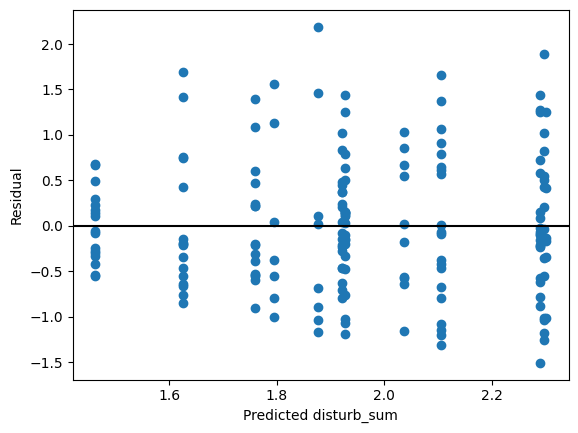

ΔR²: 0.1114153199156307
F-test vs null: p = 0.04848964904437935


/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:2274: InvalidTestWarning: F test for comparison is likely invalid with robust covariance, proceeding anyway
  warnings.warn('F test for comparison is likely invalid with ' +


In [305]:
formula = 'disturb_sum ~ values_Sol_direction'  # Use your actual feature names
m_dir = ols(formula, data=df_design).fit()
print(m_dir.summary())

# Checking residuals

residuals = m_dir.resid        # ε_i
fitted    = m_dir.fittedvalues # ŷ_i

plt.scatter(fitted, residuals)
plt.axhline(0, color='k')
plt.xlabel("Predicted disturb_sum")
plt.ylabel("Residual")
plt.show()

X0 = sm.add_constant(np.ones(len(df_sorted.iloc[:175])))
m0 = sm.OLS(y, X0).fit(cov_type='HC3')

F, p_F, _ = m_dir.compare_f_test(m0)
print("ΔR²:", m_dir.rsquared - m0.rsquared)
print("F-test vs null: p =", p_F)

### Duration

                            OLS Regression Results                            
Dep. Variable:            disturb_sum   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                 -0.008
Method:                 Least Squares   F-statistic:                    0.5333
Date:                Tue, 27 Jan 2026   Prob (F-statistic):              0.660
Time:                        15:59:09   Log-Likelihood:                -203.84
No. Observations:                 175   AIC:                             415.7
Df Residuals:                     171   BIC:                             428.3
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

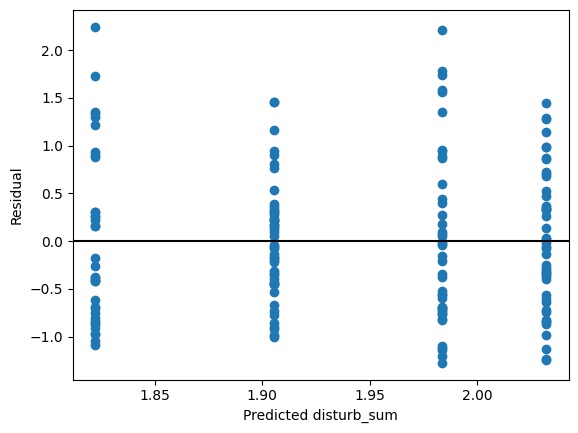

ΔR²: 0.009775256238547025
F-test vs null: p = 0.6403433122726445


/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:2274: InvalidTestWarning: F test for comparison is likely invalid with robust covariance, proceeding anyway
  warnings.warn('F test for comparison is likely invalid with ' +


In [306]:
formula = 'disturb_sum ~ values_Sol_duration'  # Use your actual feature names
m = ols(formula, data=df_design).fit(cov_type='HC3')
print(m.summary())

# Checking residuals

residuals = m.resid        # ε_i
fitted    = m.fittedvalues # ŷ_i

plt.scatter(fitted, residuals)
plt.axhline(0, color='k')
plt.xlabel("Predicted disturb_sum")
plt.ylabel("Residual")
plt.show()

X0 = sm.add_constant(np.ones(len(df_sorted.iloc[:175])))
m0 = sm.OLS(y, X0).fit(cov_type='HC3')

F, p_F, _ = m.compare_f_test(m0)
print("ΔR²:", m.rsquared - m0.rsquared)
print("F-test vs null: p =", p_F)

### Interaction duration and direction

                            OLS Regression Results                            
Dep. Variable:            disturb_sum   R-squared:                       0.266
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     1.070
Date:                Tue, 27 Jan 2026   Prob (F-statistic):              0.377
Time:                        15:59:14   Log-Likelihood:                -177.67
No. Observations:                 175   AIC:                             445.3
Df Residuals:                     130   BIC:                             587.7
Df Model:                          44                                         
Covariance Type:            nonrobust                                         
                                                            coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

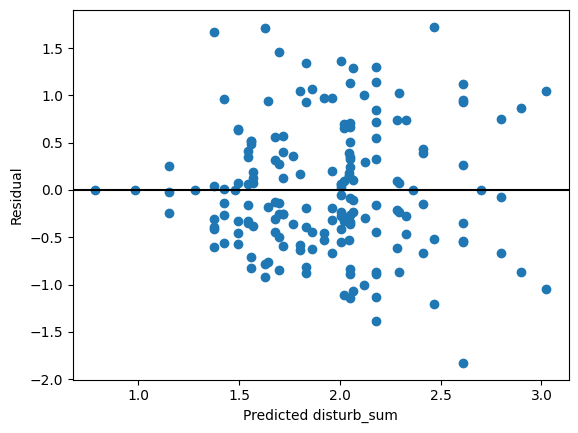

ΔR²: 0.26581615404902903
F-test vs null: p = 0.37655609111523985


In [307]:
formula = 'disturb_sum ~ values_Sol_duration * values_Sol_direction'  # Use your actual feature names
m = ols(formula, data=df_design).fit()
print(m.summary())

# Checking residuals

residuals = m.resid        # ε_i
fitted    = m.fittedvalues # ŷ_i

plt.scatter(fitted, residuals)
plt.axhline(0, color='k')
plt.xlabel("Predicted disturb_sum")
plt.ylabel("Residual")
plt.show()

X0 = sm.add_constant(np.ones(len(df_sorted.iloc[:175])))
m0 = sm.OLS(y, X0).fit()

F, p_F, _ = m.compare_f_test(m0)
print("ΔR²:", m.rsquared - m0.rsquared)
print("F-test vs null: p =", p_F)

### Gait

In [427]:
formula

'disturb_sum ~ perturb_phase_0_sin + perturb_phase_0_cos + perturb_phase_1_sin + perturb_phase_1_cos + perturb_phase_2_sin + perturb_phase_2_cos + perturb_phase_3_sin + perturb_phase_3_cos + perturb_phase_4_sin + perturb_phase_4_cos + perturb_phase_5_sin + perturb_phase_5_cos + perturb_phase_6_sin + perturb_phase_6_cos + perturb_phase_7_sin + perturb_phase_7_cos + perturb_phase_8_sin + perturb_phase_8_cos + perturb_phase_9_sin + perturb_phase_9_cos + perturb_phase_10_sin + perturb_phase_10_cos + perturb_phase_11_sin + perturb_phase_11_cos'

                            OLS Regression Results                            
Dep. Variable:            disturb_sum   R-squared:                       0.145
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     1.062
Date:                Tue, 27 Jan 2026   Prob (F-statistic):              0.393
Time:                        16:28:51   Log-Likelihood:                -190.97
No. Observations:                 175   AIC:                             431.9
Df Residuals:                     150   BIC:                             511.1
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                1.8920 

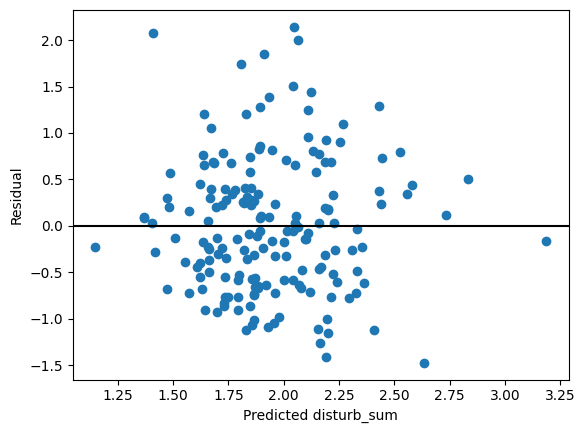

ΔR²: 0.1452964482980421
F-test vs null: p = 0.39328335252848756


In [426]:
formula = 'disturb_sum ~ ' + ' + '.join([f'perturb_phase_{i}_sin + perturb_phase_{i}_cos' for i in range(df_design.perturb_phase.values[0].shape[0])])  # For example: X1, X2, ..., X11
m = ols(formula, data=df_design).fit()
print(m.summary())

# Checking residuals

residuals = m.resid        # ε_i
fitted    = m.fittedvalues # ŷ_i

plt.scatter(fitted, residuals)
plt.axhline(0, color='k')
plt.xlabel("Predicted disturb_sum")
plt.ylabel("Residual")
plt.show()

X0 = sm.add_constant(np.ones(len(df_sorted.iloc[:175])))
m0 = sm.OLS(y, X0).fit()

F, p_F, _ = m.compare_f_test(m0)
print("ΔR²:", m.rsquared - m0.rsquared)
print("F-test vs null: p =", p_F)

                            OLS Regression Results                            
Dep. Variable:            disturb_sum   R-squared:                       0.112
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     1.702
Date:                Tue, 27 Jan 2026   Prob (F-statistic):             0.0705
Time:                        16:49:02   Log-Likelihood:                -194.31
No. Observations:                 175   AIC:                             414.6
Df Residuals:                     162   BIC:                             455.8
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            1.9074      0.061  

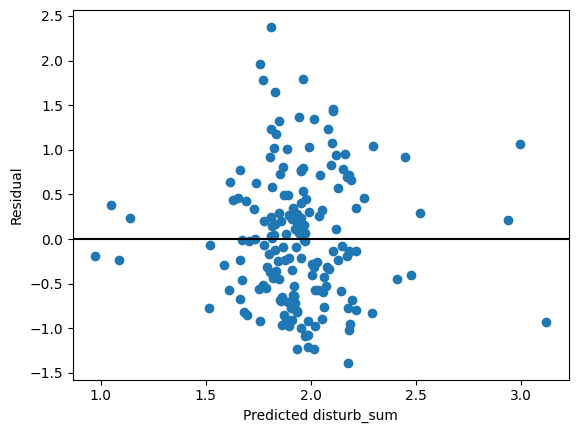

ΔR²: 0.1119826550912244
F-test vs null: p = 0.07049803486532304


In [476]:
formula = 'disturb_sum ~ ' + ' + '.join([f'perturb_phase_{i}' for i in range(df_design.perturb_phase.values[0].shape[0])])  # For example: X1, X2, ..., X11
# formula = 'disturb_sum ~ perturb_phase_1'
m = ols(formula, data=df_design).fit()
print(m.summary())

# Checking residuals

residuals = m.resid        # ε_i
fitted    = m.fittedvalues # ŷ_i

plt.scatter(fitted, residuals)
plt.axhline(0, color='k')
plt.xlabel("Predicted disturb_sum")
plt.ylabel("Residual")
plt.show()

X0 = sm.add_constant(np.ones(len(df_sorted.iloc[:175])))
m0 = sm.OLS(y, X0).fit()

F, p_F, _ = m.compare_f_test(m0)
print("ΔR²:", m.rsquared - m0.rsquared)
print("F-test vs null: p =", p_F)

In [296]:
formula

'disturb_sum ~ perturb_phase_0 + perturb_phase_1 + perturb_phase_2 + perturb_phase_3 + perturb_phase_4 + perturb_phase_5 + perturb_phase_6 + perturb_phase_7 + perturb_phase_8 + perturb_phase_9 + perturb_phase_10 + perturb_phase_11'

### Interaction gait and duration

In [359]:
formula

'disturb_sum ~ perturb_phase_0 * values_Sol_duration + perturb_phase_1 * values_Sol_duration + perturb_phase_2 * values_Sol_duration + perturb_phase_3 * values_Sol_duration + perturb_phase_4 * values_Sol_duration + perturb_phase_5 * values_Sol_duration + perturb_phase_6 * values_Sol_duration + perturb_phase_7 * values_Sol_duration + perturb_phase_8 * values_Sol_duration + perturb_phase_9 * values_Sol_duration + perturb_phase_10 * values_Sol_duration + perturb_phase_11 * values_Sol_duration'

#### Adding

                            OLS Regression Results                            
Dep. Variable:            disturb_sum   R-squared:                       0.129
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     1.565
Date:                Tue, 27 Jan 2026   Prob (F-statistic):             0.0890
Time:                        16:13:35   Log-Likelihood:                -192.65
No. Observations:                 175   AIC:                             417.3
Df Residuals:                     159   BIC:                             467.9
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

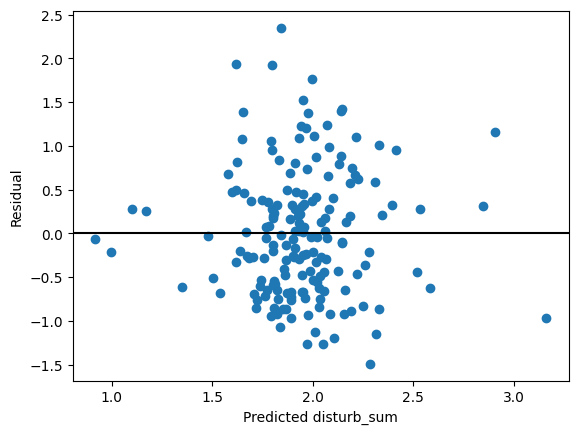

ΔR²: 0.1286656446861142
F-test vs null: p = 0.08900644506300705


In [370]:
fields = [f'perturb_phase_{i}' for i in range(12)]
interaction_terms = ' + '.join([f'{field}' for field in fields])

formula = f'disturb_sum ~ {interaction_terms} + values_Sol_duration'
m = ols(formula, data=df_design).fit()
print(m.summary())

# Checking residuals

residuals = m.resid        # ε_i
fitted    = m.fittedvalues # ŷ_i

plt.scatter(fitted, residuals)
plt.axhline(0, color='k')
plt.xlabel("Predicted disturb_sum")
plt.ylabel("Residual")
plt.show()

X0 = sm.add_constant(np.ones(len(df_sorted.iloc[:175])))
m0 = sm.OLS(y, X0).fit()

F, p_F, _ = m.compare_f_test(m0)
print("ΔR²:", m.rsquared - m0.rsquared)
print("F-test vs null: p =", p_F)


#### Interaction only

                            OLS Regression Results                            
Dep. Variable:            disturb_sum   R-squared:                       0.339
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     1.348
Date:                Tue, 27 Jan 2026   Prob (F-statistic):             0.0964
Time:                        16:14:50   Log-Likelihood:                -168.45
No. Observations:                 175   AIC:                             434.9
Df Residuals:                     126   BIC:                             590.0
Df Model:                          48                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

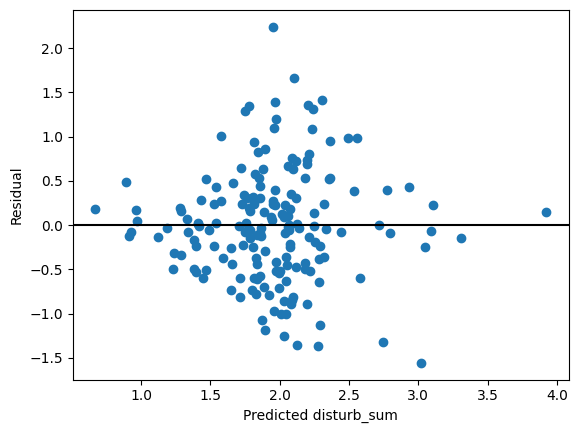

ΔR²: 0.3392452993875714
F-test vs null: p = 0.09641036150633724


In [373]:
fields = [f'perturb_phase_{i}' for i in range(12)]
interaction_terms = ' + '.join([f'{field} : values_Sol_duration' for field in fields])

formula = f'disturb_sum ~ {interaction_terms}'
m = ols(formula, data=df_design).fit()
print(m.summary())

# Checking residuals

residuals = m.resid        # ε_i
fitted    = m.fittedvalues # ŷ_i

plt.scatter(fitted, residuals)
plt.axhline(0, color='k')
plt.xlabel("Predicted disturb_sum")
plt.ylabel("Residual")
plt.show()

X0 = sm.add_constant(np.ones(len(df_sorted.iloc[:175])))
m0 = sm.OLS(y, X0).fit()

F, p_F, _ = m.compare_f_test(m0)
print("ΔR²:", m.rsquared - m0.rsquared)
print("F-test vs null: p =", p_F)


#### Everything and interaction

                            OLS Regression Results                            
Dep. Variable:            disturb_sum   R-squared:                       0.345
Model:                            OLS   Adj. R-squared:                  0.074
Method:                 Least Squares   F-statistic:                     1.271
Date:                Tue, 27 Jan 2026   Prob (F-statistic):              0.144
Time:                        16:15:35   Log-Likelihood:                -167.66
No. Observations:                 175   AIC:                             439.3
Df Residuals:                     123   BIC:                             603.9
Df Model:                          51                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

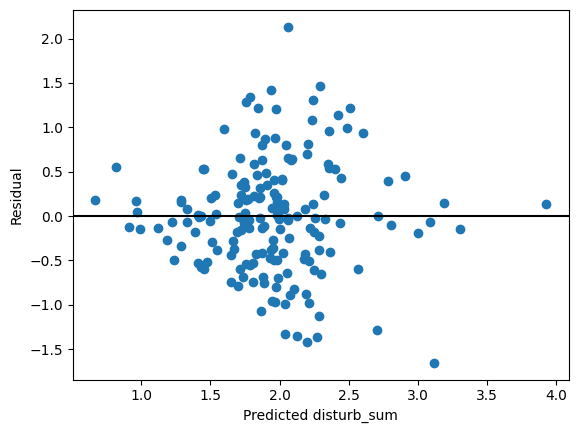

ΔR²: 0.345133882728075
F-test vs null: p = 0.14372772403547895


In [374]:
fields = [f'perturb_phase_{i}' for i in range(12)]
interaction_terms = ' + '.join([f'{field} * values_Sol_duration' for field in fields])

formula = f'disturb_sum ~ {interaction_terms}'
m = ols(formula, data=df_design).fit()
print(m.summary())

# Checking residuals

residuals = m.resid        # ε_i
fitted    = m.fittedvalues # ŷ_i

plt.scatter(fitted, residuals)
plt.axhline(0, color='k')
plt.xlabel("Predicted disturb_sum")
plt.ylabel("Residual")
plt.show()

X0 = sm.add_constant(np.ones(len(df_sorted.iloc[:175])))
m0 = sm.OLS(y, X0).fit()

F, p_F, _ = m.compare_f_test(m0)
print("ΔR²:", m.rsquared - m0.rsquared)
print("F-test vs null: p =", p_F)


### Interaction gait and direction

#### Adding

                            OLS Regression Results                            
Dep. Variable:            disturb_sum   R-squared:                       0.213
Model:                            OLS   Adj. R-squared:                  0.094
Method:                 Least Squares   F-statistic:                     1.780
Date:                Tue, 27 Jan 2026   Prob (F-statistic):             0.0216
Time:                        16:07:38   Log-Likelihood:                -183.71
No. Observations:                 175   AIC:                             415.4
Df Residuals:                     151   BIC:                             491.4
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

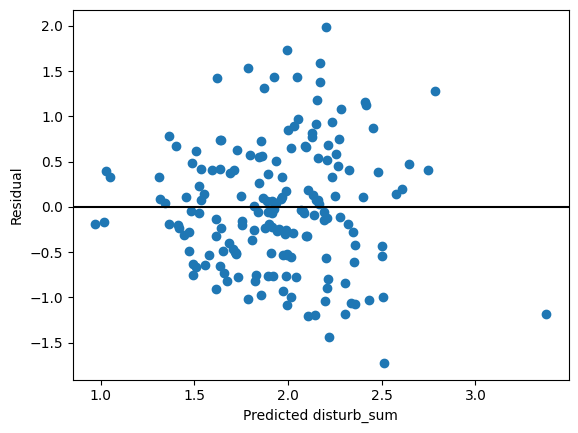

ΔR²: 0.2133316778137353
F-test vs null: p = 0.02156557389087338


In [347]:
fields = [f'perturb_phase_{i}' for i in range(12)]
interaction_terms = ' + '.join([f'{field}' for field in fields])

formula = f'disturb_sum ~ {interaction_terms} + values_Sol_direction'
m = ols(formula, data=df_design).fit()
print(m.summary())

# Checking residuals

residuals = m.resid        # ε_i
fitted    = m.fittedvalues # ŷ_i

plt.scatter(fitted, residuals)
plt.axhline(0, color='k')
plt.xlabel("Predicted disturb_sum")
plt.ylabel("Residual")
plt.show()

X0 = sm.add_constant(np.ones(len(df_sorted.iloc[:175])))
m0 = sm.OLS(y, X0).fit()

F, p_F, _ = m.compare_f_test(m0)
print("ΔR²:", m.rsquared - m0.rsquared)
print("F-test vs null: p =", p_F)


#### Interaction only

                            OLS Regression Results                            
Dep. Variable:            disturb_sum   R-squared:                       0.752
Model:                            OLS   Adj. R-squared:                  0.083
Method:                 Least Squares   F-statistic:                     1.124
Date:                Tue, 27 Jan 2026   Prob (F-statistic):              0.330
Time:                        16:14:14   Log-Likelihood:                -82.600
No. Observations:                 175   AIC:                             421.2
Df Residuals:                      47   BIC:                             826.3
Df Model:                         127                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

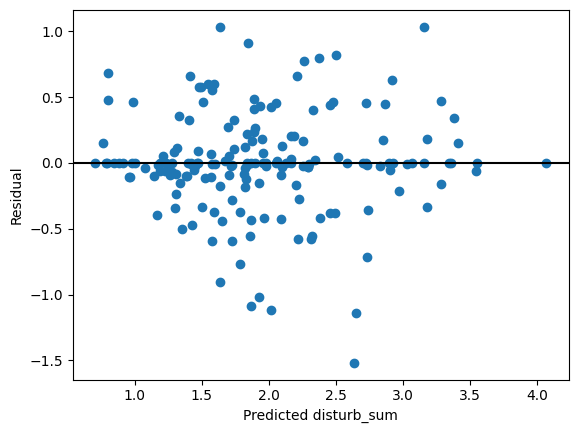

ΔR²: 0.7522865875163206
F-test vs null: p = 0.3296980565918587


In [371]:
fields = [f'perturb_phase_{i}' for i in range(12)]
interaction_terms = ' + '.join([f'{field} : values_Sol_direction' for field in fields])

formula = f'disturb_sum ~ {interaction_terms}'
m = ols(formula, data=df_design).fit()
print(m.summary())

# Checking residuals

residuals = m.resid        # ε_i
fitted    = m.fittedvalues # ŷ_i

plt.scatter(fitted, residuals)
plt.axhline(0, color='k')
plt.xlabel("Predicted disturb_sum")
plt.ylabel("Residual")
plt.show()

X0 = sm.add_constant(np.ones(len(df_sorted.iloc[:175])))
m0 = sm.OLS(y, X0).fit()

F, p_F, _ = m.compare_f_test(m0)
print("ΔR²:", m.rsquared - m0.rsquared)
print("F-test vs null: p =", p_F)


#### Everything and interaction

                            OLS Regression Results                            
Dep. Variable:            disturb_sum   R-squared:                       0.782
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     1.070
Date:                Tue, 27 Jan 2026   Prob (F-statistic):              0.414
Time:                        16:12:53   Log-Likelihood:                -71.466
No. Observations:                 175   AIC:                             412.9
Df Residuals:                      40   BIC:                             840.2
Df Model:                         134                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

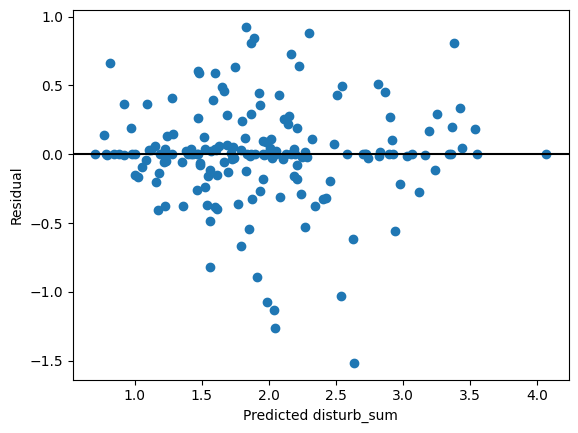

ΔR²: 0.7818831237178198
F-test vs null: p = 0.41400868027294074


In [369]:
fields = [f'perturb_phase_{i}' for i in range(12)]
interaction_terms = ' + '.join([f'{field} * values_Sol_direction' for field in fields])

formula = f'disturb_sum ~ {interaction_terms}'
m = ols(formula, data=df_design).fit()
print(m.summary())

# Checking residuals

residuals = m.resid        # ε_i
fitted    = m.fittedvalues # ŷ_i

plt.scatter(fitted, residuals)
plt.axhline(0, color='k')
plt.xlabel("Predicted disturb_sum")
plt.ylabel("Residual")
plt.show()

X0 = sm.add_constant(np.ones(len(df_sorted.iloc[:175])))
m0 = sm.OLS(y, X0).fit()

F, p_F, _ = m.compare_f_test(m0)
print("ΔR²:", m.rsquared - m0.rsquared)
print("F-test vs null: p =", p_F)


### Interaction of everything. Best is perturb_phase 1

In [429]:
formula

'disturb_sum ~ perturb_phase_0_sin * values_Sol_direction * values_Sol_duration + perturb_phase_1_sin * values_Sol_direction * values_Sol_duration + perturb_phase_2_sin * values_Sol_direction * values_Sol_duration + perturb_phase_3_sin * values_Sol_direction * values_Sol_duration + perturb_phase_4_sin * values_Sol_direction * values_Sol_duration + perturb_phase_5_sin * values_Sol_direction * values_Sol_duration + perturb_phase_6_sin * values_Sol_direction * values_Sol_duration + perturb_phase_7_sin * values_Sol_direction * values_Sol_duration + perturb_phase_8_sin * values_Sol_direction * values_Sol_duration + perturb_phase_9_sin * values_Sol_direction * values_Sol_duration + perturb_phase_10_sin * values_Sol_direction * values_Sol_duration + perturb_phase_11_sin * values_Sol_direction * values_Sol_duration'

                            OLS Regression Results                            
Dep. Variable:            disturb_sum   R-squared:                       0.607
Model:                            OLS   Adj. R-squared:                  0.249
Method:                 Least Squares   F-statistic:                     1.696
Date:                Tue, 27 Jan 2026   Prob (F-statistic):            0.00707
Time:                        17:16:26   Log-Likelihood:                -122.90
No. Observations:                 175   AIC:                             413.8
Df Residuals:                      91   BIC:                             679.6
Df Model:                          83                                         
Covariance Type:            nonrobust                                         
                                                                            coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

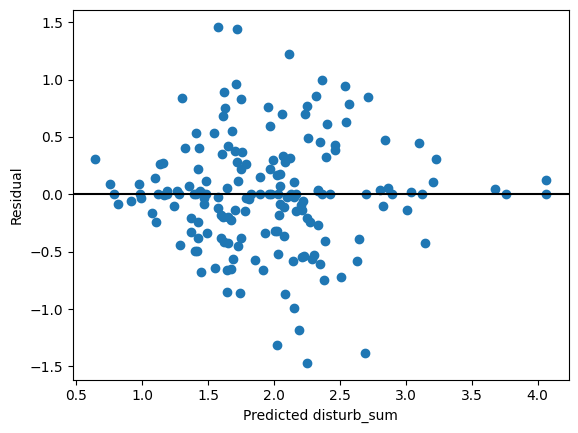

ΔR²: 0.6073966818347248
F-test vs null: p = 0.00707008706449374


In [534]:
formula = f'disturb_sum ~ perturb_phase_1 * values_Sol_direction * values_Sol_duration'
# fields = [f'perturb_phase_{i}_sin' for i in range(12)]
# interaction_terms = ' + '.join([f'{field} * values_Sol_direction * values_Sol_duration' for field in fields])

# formula = f'disturb_sum ~ {interaction_terms}'
m = ols(formula, data=df_design).fit()
print(m.summary())

# Checking residuals

residuals = m.resid        # ε_i
fitted    = m.fittedvalues # ŷ_i

plt.scatter(fitted, residuals)
plt.axhline(0, color='k')
plt.xlabel("Predicted disturb_sum")
plt.ylabel("Residual")
plt.show()

X0 = sm.add_constant(np.ones(len(df_sorted.iloc[:175])))
m0 = sm.OLS(y, X0).fit()

F, p_F, _ = m.compare_f_test(m0)
print("ΔR²:", m.rsquared - m0.rsquared)
print("F-test vs null: p =", p_F)


In [48]:
formula

'disturb_sum ~ perturb_phase_11_sin * values_Sol_direction * values_Sol_duration + perturb_phase_11_cos * values_Sol_direction * values_Sol_duration'

                            OLS Regression Results                            
Dep. Variable:            disturb_sum   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.291
Method:                 Least Squares   F-statistic:                     1.621
Date:                Wed, 28 Jan 2026   Prob (F-statistic):             0.0207
Time:                        09:00:46   Log-Likelihood:                -79.997
No. Observations:                 175   AIC:                             392.0
Df Residuals:                      59   BIC:                             759.1
Df Model:                         115                                         
Covariance Type:            nonrobust                                         
                                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

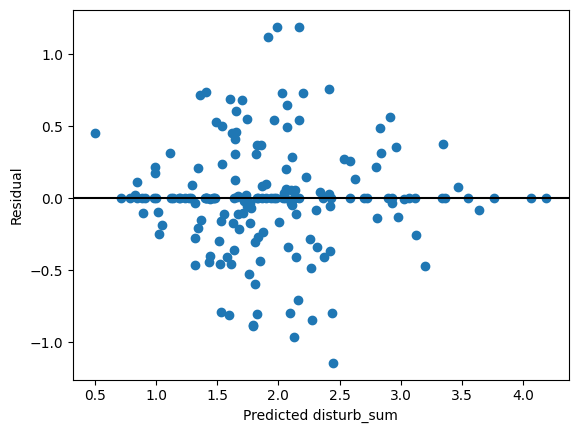

NameError: name 'y' is not defined

In [47]:
# for i in range(12):
i = 11
formula = f'disturb_sum ~ perturb_phase_{i}_sin * values_Sol_direction * values_Sol_duration + perturb_phase_{i}_cos * values_Sol_direction * values_Sol_duration'
m = ols(formula, data=df_design).fit()
print(m.summary())

# Checking residuals

residuals = m.resid        # ε_i
fitted    = m.fittedvalues # ŷ_i

plt.scatter(fitted, residuals)
plt.axhline(0, color='k')
plt.xlabel("Predicted disturb_sum")
plt.ylabel("Residual")
plt.show()

X0 = sm.add_constant(np.ones(len(df_sorted.iloc[:175])))
m0 = sm.OLS(y, X0).fit()

F, p_F, _ = m.compare_f_test(m0)
print("ΔR²:", m.rsquared - m0.rsquared)
print("F-test vs null: p =", p_F)


In [580]:
r2s = []
for i in range(12):
    formula = f'disturb_sum ~ perturb_phase_{i}_sin * values_Sol_direction * values_Sol_duration + perturb_phase_{i}_cos * values_Sol_direction * values_Sol_duration'
    # formula = f'disturb_sum ~ perturb_phase_{i} * values_Sol_direction * values_Sol_duration'
    m = ols(formula, data=df_design).fit()
    r2s.append(m.f_pvalue)
    print(m.f_pvalue)


0.18657936772510245
0.01952039735543839
0.1371184782567737
0.13658649939533868
0.02021166248028904
0.014858520805978973
0.007961540719987618
0.015265861439450445
0.02209749086948157
0.042846093292366674
0.024005027640591075
0.02071592348573565


In [41]:
print(m.summary())

                            OLS Regression Results                            
Dep. Variable:            disturb_sum   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.291
Method:                 Least Squares   F-statistic:                     1.621
Date:                Wed, 28 Jan 2026   Prob (F-statistic):             0.0207
Time:                        08:57:50   Log-Likelihood:                -79.997
No. Observations:                 175   AIC:                             392.0
Df Residuals:                      59   BIC:                             759.1
Df Model:                         115                                         
Covariance Type:            nonrobust                                         
                                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

## Stats figures

In [124]:
df_design = df_sorted.copy()
df_design = df_design.iloc[:175]
df_design['disturb_sum'] = df_design['disturb_score'].apply(lambda a: np.log(np.abs(np.sum(a))))
for idx in range(df_design.perturb_phase.values[0].shape[0]):
    df_design[f'perturb_phase_{idx}_sin'] = np.sin(np.stack(df_design.perturb_phase.values)[:, idx])
    df_design[f'perturb_phase_{idx}_cos'] = np.cos(np.stack(df_design.perturb_phase.values)[:, idx])
    df_design[f'perturb_phase_{idx}'] = np.stack(df_design.perturb_phase.values)[:, idx]

In [125]:
def run_ols(formula, df):
    m = ols(formula, data=df).fit()
    return m.f_pvalue, m.rsquared_adj, m.rsquared

In [126]:
indv_phase_dir_dur = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i} + values_Sol_direction + values_Sol_duration'
    for i in range(12)
}
indv_phase_rad = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i}'
    for i in range(12)
}

# Individual + durations
indv_phase_rad_sum_dur = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i} + values_Sol_duration'
    for i in range(12)
}
indv_phase_rad_inter_dur = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i} : values_Sol_duration'
    for i in range(12)
}
indv_phase_rad_full_dur = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i} * values_Sol_duration'
    for i in range(12)
}
indv_phase_sin_cos_sum_dur = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i}_sin + perturb_phase_{i}_cos + values_Sol_duration'
    for i in range(12)
}
indv_phase_sin_cos_inter_dur = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i}_sin : values_Sol_duration + perturb_phase_{i}_cos : values_Sol_duration'
    for i in range(12)
}
indv_phase_sin_cos_full_dur = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i}_sin * values_Sol_duration + perturb_phase_{i}_cos * values_Sol_duration'
    for i in range(12)
}

# Individual + direction
indv_phase_rad_sum_dir = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i} + values_Sol_direction'
    for i in range(12)
}
indv_phase_rad_inter_dir = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i} : values_Sol_direction'
    for i in range(12)
}
indv_phase_rad_full_dir = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i} * values_Sol_direction'
    for i in range(12)
}
indv_phase_sin_cos_sum_dir = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i}_sin + perturb_phase_{i}_cos + values_Sol_direction'
    for i in range(12)
}
indv_phase_sin_cos_inter_dir = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i}_sin : values_Sol_direction + perturb_phase_{i}_cos : values_Sol_direction'
    for i in range(12)
}
indv_phase_sin_cos_full_dir = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i}_sin * values_Sol_direction + perturb_phase_{i}_cos * values_Sol_direction'
    for i in range(12)
}



indv_phase_sin_cos = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i}_sin + perturb_phase_{i}_cos'
    for i in range(12)
}
indv_phase_dir_dur_sin_cos = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i}_sin + perturb_phase_{i}_cos + values_Sol_direction + values_Sol_duration'
    for i in range(12) 
}
idv_phase_times_dir_dur = {
    f'phase{i}':  f'disturb_sum ~ perturb_phase_{i} * values_Sol_direction * values_Sol_duration'
    for i in range(12)  # 
}
idv_phase_sin_cos_times_dir_dur = {
    f'phase{i}':  f'disturb_sum ~ perturb_phase_{i}_sin * values_Sol_direction * values_Sol_duration + perturb_phase_{i}_cos * values_Sol_direction * values_Sol_duration'
    for i in range(12)  
}
formulas = {
    'dir': 'disturb_sum ~ values_Sol_direction',
    'dur': 'disturb_sum ~ values_Sol_duration',
    'dur+dir': 'disturb_sum ~ values_Sol_duration + values_Sol_direction',
    'dur:dir': 'disturb_sum ~ values_Sol_duration : values_Sol_direction',
    'dur*dir': 'disturb_sum ~ values_Sol_duration * values_Sol_direction',
    'all_phases_rad': 'disturb_sum ~ ' + ' + '.join([f'perturb_phase_{i}' for i in range(df_design.perturb_phase.values[0].shape[0])]),
    'indv_phase_rad' : indv_phase_rad,
    'all_phases_sin_cos': 'disturb_sum ~ ' + ' + '.join([f'perturb_phase_{i}_sin + perturb_phase_{i}_cos' for i in range(df_design.perturb_phase.values[0].shape[0])]),
    'indv_phase_sin_cos' : indv_phase_sin_cos,
    # 'phase_1_rad': 'disturb_sum ~ perturb_phase_1',
    # 'phase_1_sin_cos': 'disturb_sum ~ perturb_phase_1_sin + perturb_phase_1_cos',
    'phase_all+dur': f'disturb_sum ~ {" + ".join([f"perturb_phase_{i}" for i in range(12)])} + values_Sol_duration',
    'phase_all:dur': f'disturb_sum ~ {" + ".join([f"perturb_phase_{i} : values_Sol_duration" for i in range(12)])}',
    'phase_all*dur': f'disturb_sum ~ {" + ".join([f"perturb_phase_{i} * values_Sol_duration" for i in range(12)])}',
    'idv_phase_rad+dur': indv_phase_rad_sum_dur,
    'idv_phase_rad:dur': indv_phase_rad_inter_dur,
    'idv_phase_rad*dur': indv_phase_rad_full_dur,
    'idv_phase_sin_cos+dur': indv_phase_sin_cos_sum_dur,
    'idv_phase_sin_cos:dur': indv_phase_sin_cos_inter_dur,
    'idv_phase_sin_cos*dur': indv_phase_sin_cos_full_dur,
    'phase_all+dir': f'disturb_sum ~ {" + ".join([f"perturb_phase_{i}" for i in range(12)])} + values_Sol_direction',
    'phase_all:dir': f'disturb_sum ~ {" + ".join([f"perturb_phase_{i} : values_Sol_direction" for i in range(12)])}',
    'phase_all*dir': f'disturb_sum ~ {" + ".join([f"perturb_phase_{i} * values_Sol_direction" for i in range(12)])}',
    'idv_phase_rad+dir': indv_phase_rad_sum_dir,
    'idv_phase_rad:dir': indv_phase_rad_inter_dir,
    'idv_phase_rad*dir': indv_phase_rad_full_dir,
    'idv_phase_sin_cos+dir': indv_phase_sin_cos_sum_dir,
    'idv_phase_sin_cos:dir': indv_phase_sin_cos_inter_dir,
    'idv_phase_sin_cos*dir': indv_phase_sin_cos_full_dir,
    'indv_phase_rad+dir+dur' : indv_phase_dir_dur,
    'indv_phase_sin_cos+dir+dur' : indv_phase_dir_dur_sin_cos,
    'indv_phase_rad*dir*dur': idv_phase_times_dir_dur,
    'indv_phase_sin_cos*dir*dur': idv_phase_sin_cos_times_dir_dur
}
res = {}
for key in formulas.keys():
    if type(formulas[key]) != dict:
        res[key] = run_ols(formulas[key], df_design)
    else:
        r2s_adj, pvals, r2s = [], [], []
        for sub_key, value in formulas[key].items():
            pval, r2_adj, r2 = run_ols(value, df_design)
            r2s_adj.append(r2_adj)
            pvals.append(pval)
            r2s.append(r2)
        res[key] = (pvals, r2s_adj, r2s)


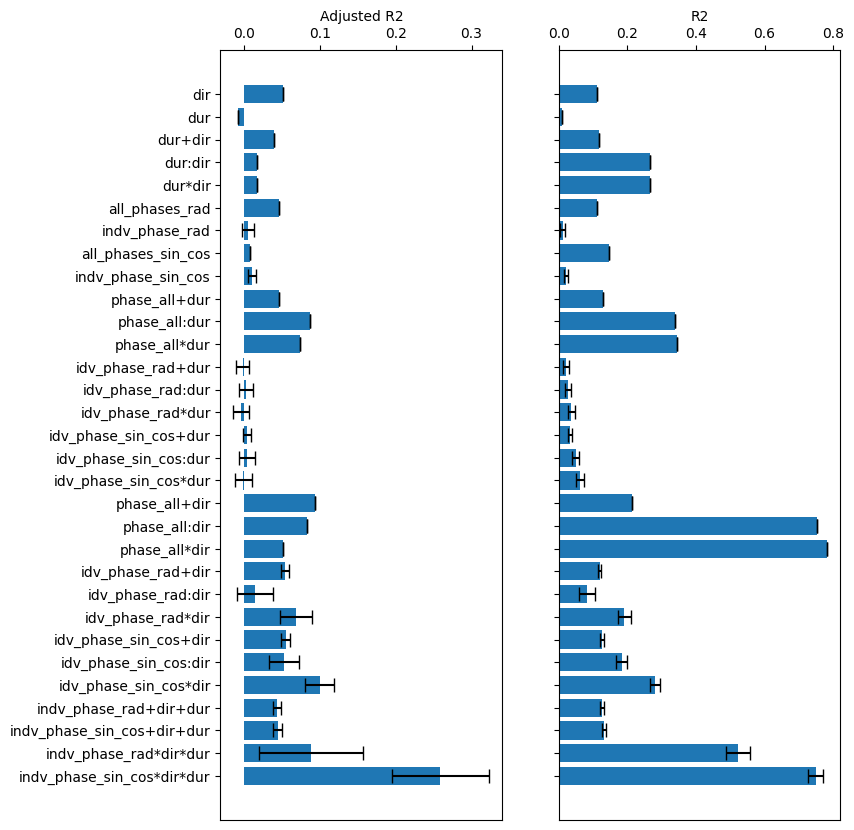

<Figure size 640x480 with 0 Axes>

In [127]:
fig, axs = plt.subplots(1, 2, figsize=(8, 10), sharey='all')

# Loop through res.values() and check if val[1] is a list
means = [np.mean(val[1]) if isinstance(val[1], list) else val[1] for val in res.values()]
stds = [np.std(val[1]) if isinstance(val[1], list) else 0 for val in res.values()]  # Use 0 if not a list for std

# Horizontal bars
axs[0].barh(list(res.keys()), means)
axs[0].errorbar(means, list(res.keys()), xerr=stds, fmt='none', color='black', capsize=5)
axs[0].invert_yaxis()

plt.yticks(rotation=0)  # Ensure y-ticks are horizontal
axs[0].set_xlabel('Adjusted R2')
axs[0].xaxis.set_ticks_position('top')
axs[0].xaxis.set_label_position('top')

# # Loop through res.values() and check if val[1] is a list
means = [np.mean(val[2]) if isinstance(val[2], list) else val[2] for val in res.values()]
stds = [np.std(val[2]) if isinstance(val[2], list) else 0 for val in res.values()]  # Use 0 if not a list for std

# # Horizontal bars
axs[1].barh(list(res.keys()), means)
axs[1].errorbar(means, list(res.keys()), xerr=stds, fmt='none', color='black', capsize=5)
# axs[1].invert_yaxis()

# plt.yticks(rotation=0)  # Ensure y-ticks are horizontal
axs[1].set_xlabel('R2')
axs[1].xaxis.set_ticks_position('top')
axs[1].xaxis.set_label_position('top')
plt.show()
plt.tight_layout()


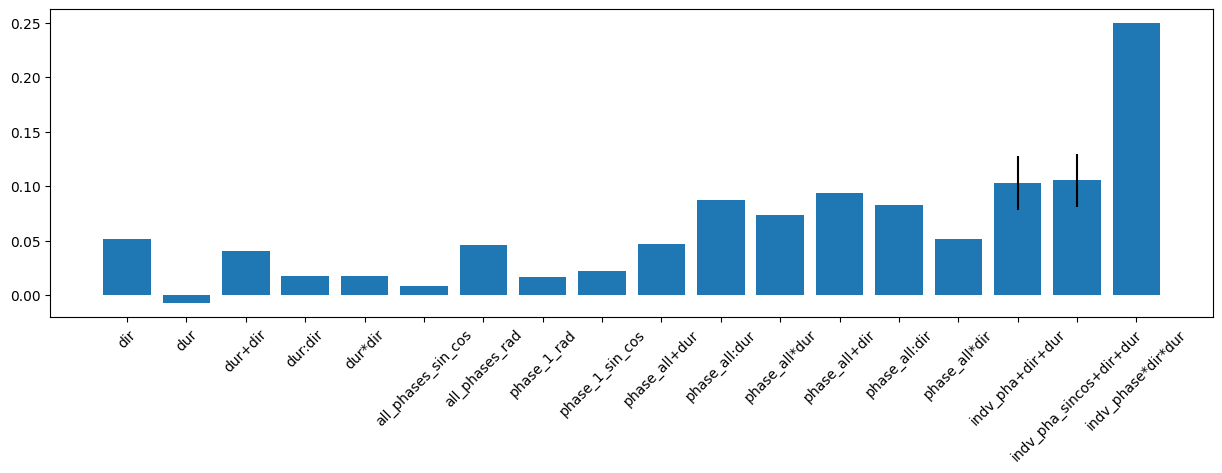

In [543]:
fig, ax = plt.subplots(figsize=(15, 4))

# Loop through res.values() and check if val[1] is a list
means = [np.mean(val[1]) if isinstance(val[1], list) else val[1] for val in res.values()]
stds = [np.std(val[1]) if isinstance(val[1], list) else 0 for val in res.values()]  # Use 0 if not a list for std

ax.bar(res.keys(), means)

# Adding error bars where val[1] is a list
ax.errorbar(res.keys(), means, yerr=stds, fmt='none', color='black', capsize=0)

plt.xticks(rotation=45)
plt.show()

### Predictions

In [744]:
df_design = df_sorted.copy()
df_design = df_design.iloc[:]
df_design['disturb_sum'] = df_design['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))
for idx in range(df_design.perturb_phase.values[0].shape[0]):
    df_design[f'perturb_phase_{idx}_sin'] = np.sin(np.stack(df_design.perturb_phase.values)[:, idx])
    df_design[f'perturb_phase_{idx}_cos'] = np.cos(np.stack(df_design.perturb_phase.values)[:, idx])
    df_design[f'perturb_phase_{idx}'] = np.stack(df_design.perturb_phase.values)[:, idx]

In [745]:
df_design_ = df_design.sample(frac=1, random_state=42).reset_index(drop=True)

In [707]:
res = {}

In [786]:
n_trials = len(df_design)

############ Generate one-hot encodings ############
values_Sol_direction = df_design_.values_Sol_direction.values
values_Sol_duration = df_design_.values_Sol_duration.values
direction_one_hot = np.eye(12)[values_Sol_direction.astype(int)]

duration_mapping = {50: 0, 100: 1, 150: 2, 200: 3}
duration_mapped = np.array([duration_mapping[val] if val in duration_mapping else -1 for val in df_design_.values_Sol_duration.values])
if np.any(duration_mapped == -1):
    print("Warning: Some values in 'values_Sol_duration' are not 50, 100, 150, or 200.")
duration_one_hot = np.eye(4)[duration_mapped] 

dir_dur_base = (direction_one_hot[:, :, None] * duration_one_hot[:, None, :]).reshape(-1, 48)

#### with neural data
mop_pre_perturb = np.stack(df_design_.MOp_rates_pca_concat)[:, 250:301, :]
mop_pre_perturb = mop_pre_perturb.reshape(n_trials, -1)
mop_int_dir = (mop_pre_perturb[:, :, None] * direction_one_hot[:, None, :]).reshape(n_trials, -1)
mop_int_dur = (mop_pre_perturb[:, :, None] * duration_one_hot[:, None, :]).reshape(n_trials, -1)


cp_pre_perturb = np.stack(df_design_.CP_rates_pca_concat)[:, 250:300, :]
cp_pre_perturb = cp_pre_perturb.reshape(n_trials, -1)
cp_int_dir = (cp_pre_perturb[:, :, None] * direction_one_hot[:, None, :]).reshape(n_trials, -1)
cp_int_dur = (cp_pre_perturb[:, :, None] * duration_one_hot[:, None, :]).reshape(n_trials, -1)



# SSp_pre_perturb = np.stack(df_design_.SSp_rates_pca_concat)[:, :300, :]
# SSp_pre_perturb = SSp_pre_perturb.reshape(n_trials, -1)

val_pre_perturb = np.stack(df_design_.VAL_rates_pca_concat)[:, :300, :]
val_pre_perturb = val_pre_perturb.reshape(n_trials, -1)
val_int_dur = (val_pre_perturb[:, :, None] * duration_one_hot[:, None, :]).reshape(n_trials, -1)




X_final = np.column_stack([
    # --- Main Effects ---
    direction_one_hot, 
    duration_one_hot,
    dir_dur_base,
    # mop_int_dir,
    # mop_int_dur,
    # cp_int_dir,
    # cp_int_dur,
    # val_int_dur
    # mop_pre_perturb,
    # cp_pre_perturb,
    # SSp_pre_perturb,
    # val_pre_perturb

])

for i in [1]:

    perturb_phase_sin = df_design_[f'perturb_phase_{i}_sin'].values
    perturb_phase_cos = df_design_[f'perturb_phase_{i}_cos'].values

    ############ Generate interactions ############

    interaction_sin_dir = perturb_phase_sin[:, None] * direction_one_hot
    interaction_cos_dir = perturb_phase_cos[:, None] * direction_one_hot

    interaction_sin_dur = perturb_phase_sin[:, None] * duration_one_hot
    interaction_cos_dur = perturb_phase_cos[:, None] * duration_one_hot

    X_final = np.column_stack([
        X_final,
        
        # With phases
        perturb_phase_sin, 
        perturb_phase_cos,

        # --- 2-Way Interactions ---
        # interaction_sin_dir, 
        # interaction_cos_dir,
        # interaction_sin_dur, 
        # interaction_cos_dur,

        # # interactions with neural data
        perturb_phase_sin.reshape(-1, 1) * mop_pre_perturb[:, :],
        perturb_phase_cos.reshape(-1, 1) * mop_pre_perturb[:, :],
        
        # # # --- 3-Way Interactions (The "Full" interaction) ---
        perturb_phase_sin[:, None] * dir_dur_base,
        perturb_phase_cos[:, None] * dir_dur_base,
    ])
print(X_final.shape)
r2s = cross_val_score(
    Ridge(alpha=10), 
    X=X_final,
    y=df_design_.disturb_sum.values,
    cv=4,
    scoring=decode.get_custom_scorer()
)

res['neural'] = r2s
print(r2s.mean(), r2s.std())

(257, 18318)
0.005300027810849536 0.0034199064044643057


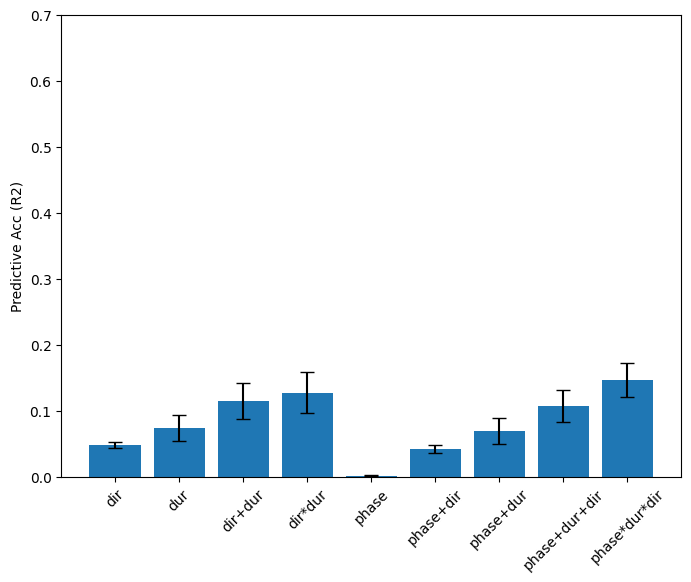

In [756]:
fig, ax = plt.subplots(figsize=(8, 6))

# Loop through res.values() and check if val[1] is a list
means = [np.mean(val) for val in res.values()]
stds = [np.std(val) for val in res.values()]  # Use 0 if not a list for std

ax.bar(res.keys(), means)

# Adding error bars where val[1] is a list
ax.errorbar(res.keys(), means, yerr=stds, fmt='none', color='black', capsize=5)
ax.set_ylim(0, 0.7)
ax.set_ylabel('Predictive Acc (R2)')
plt.xticks(rotation=45)
plt.show()